# Notebook 08 — Cyanobacteria Detection: Normalisation Sensitivity Analysis

**Dataset:** L. Võrtsjärv (Estonia) — Hypstar radiometer, 2023–2024  
**Contributor:** Kersti (Case Study 3, AQUATIME)

## Scientific context

The second derivative of water reflectance at **552.5 nm** (D²(552)) is used to detect cyanobacteria  
(Lubac et al. 2008). The signal exploits the phycocyanin absorption trough near 620 nm, which creates  
a local reflectance peak around 550–560 nm unique to cyanobacteria:  
- **D²(552) < 0** → cyanobacteria signal present  
- **D²(552) ≥ 0** → no cyanobacteria dominance  

In-situ wet-weight data from L. Võrtsjärv confirms this relationship over two years.

## Open question addressed here

> *Does the normalisation wavelength used before computing D² affect the sign and amplitude*  
> *of D²(552), and therefore the cyanobacteria classification?*

We test four strategies:

| ID | Norm wavelength | Notes |
|----|----------------|-------|
| `raw` | None (no normalisation) | Directly differentiate ρw |
| `442` | 442.5 nm (index 35) | `phytospec` RT1 default (R-pipeline compatible) |
| `620` | 620 nm | Lubac (2008) paper convention; phycocyanin absorption |
| `665` | 665 nm | Testing based on in-situ analysis |

---

## 1. Imports and configuration

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ── phytospec imports ──────────────────────────────────────────────────────────
# All spectral algorithms are called from the official phytospec package.
from phytospec import algorithms as alg   # alg.compute_D2(), alg.interp_at()
from phytospec import config as cfg       # cfg.D2_DELTA, cfg.D2_N_SMOOTH, ...

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('phytospec imported ✓')
print(f'  Default D2_NORM_WL  : {cfg.D2_NORM_WL}')
print(f'  Default D2_DELTA    : {cfg.D2_DELTA} nm')
print(f'  Default D2_N_SMOOTH : {cfg.D2_N_SMOOTH}')

phytospec imported ✓
  Default D2_NORM_WL  : None
  Default D2_DELTA    : 2.5 nm
  Default D2_N_SMOOTH : 2


In [101]:

# ── Load data ─────────────────────────────────────────────────────────────────
DATA_FILE = cfg.DATA_RAW / "Hypstar_radiometric_23-24.csv"

# ── Analysis parameters ────────────────────────────────────────────────────────
TARGET_WL = 552.5          # nm — D² evaluated here for Cy detection
N_SMOOTH  = cfg.D2_N_SMOOTH  # 2 smoothing passes (Lubac 2008 standard)
STATION   = 'L. Võrtsjärv'

# ── Four normalisation configurations ─────────────────────────────────────────
# Each entry: (key, norm_wl passed to alg.compute_D2, display label, colour)
#   norm_wl = None   → index 35 = 442.5 nm  (RT1 / R-pipeline default)
#   norm_wl = float  → nearest grid point to that wavelength
#   norm_wl = 'raw'  → no normalisation — differentiate ρw directly
NORM_CONFIGS = [
    ('raw', 'raw',  'No normalisation',         '#1b7837'),
    ('442', None,   'Norm 442.5 nm  (idx 35)',   '#2166ac'),
    ('620', 620.0,  'Norm 620 nm  (Lubac 2008)', '#d6604d'),
    ('665', 665.0,  'Norm 665 nm  (Testing)',      '#b58900'),
]

NORM_DICT = {k: (wl_n, lbl, col) for k, wl_n, lbl, col in NORM_CONFIGS}
print('Parameters set ✓')

Parameters set ✓


## 2. Analysis parameters and phytospec configuration

`phytospec.algorithms.compute_D2` accepts three keyword overrides:
- `norm_wl`  — normalisation wavelength (`float`, `None` → index 35, or `'raw'`)
- `delta`    — wavelength step **in nm** — must match the sensor grid
- `n_smooth` — number of 5-pt smoothing passes

We pass `delta` from the actual Hypstar grid (~0.49 nm) rather than  
`cfg.D2_DELTA` (2.5 nm, set for PANTHYR). The denominator `delta²` means  
absolute D² magnitudes differ by ~26× between sensors — **never apply  
PANTHYR thresholds directly to Hypstar data**.

## 3. Load data

In [128]:
df    = pd.read_csv(DATA_FILE)
dates = pd.to_datetime(df['Date'].astype(str), format='%Y%m%d')
wl    = df.columns[1:].astype(float).values
RHOW  = df.iloc[:, 1:].values.astype(float)

# Wavelength step — critical: must reflect actual sensor grid
delta = float(np.median(np.diff(wl)))

print(f'Station    : {STATION}')
print(f'Spectra    : {len(dates)}')
print(f'Wavelengths: {len(wl)}  ({wl[0]:.1f} – {wl[-1]:.1f} nm)')
print(f'Δλ         : {delta:.4f} nm')
print(f'Date range : {dates.min().date()} → {dates.max().date()}')
print(f'Index 35   : {wl[35]:.1f} nm  (= 442.5 nm for PANTHYR; {wl[35]:.1f} nm here)')
print (wl)


Station    : L. Võrtsjärv
Spectra    : 129
Wavelengths: 1536  (350.4 – 1099.8 nm)
Δλ         : 0.4909 nm
Date range : 2023-05-07 → 2024-11-18
Index 35   : 366.7 nm  (= 442.5 nm for PANTHYR; 366.7 nm here)
[ 350.44504887  350.90929219  351.37360137 ... 1098.86684821 1099.33994336
 1099.81295133]


## 4. Overview: reflectance spectra

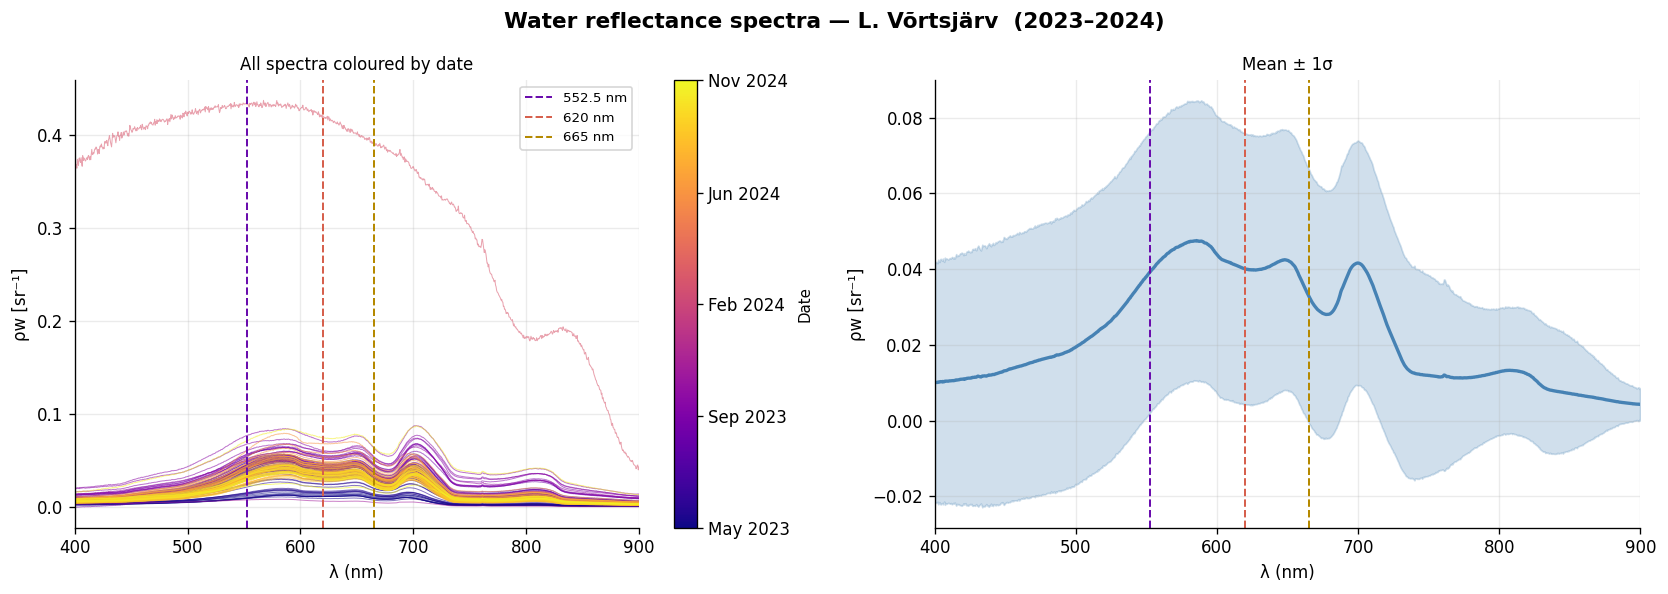

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Water reflectance spectra — {STATION}  ({dates.min().year}–{dates.max().year})',
             fontsize=13, fontweight='bold')

# Left: all spectra coloured by date
ax = axes[0]
cmap = plt.cm.plasma
norm_c = plt.Normalize(vmin=dates.min().toordinal(), vmax=dates.max().toordinal())
mask_wl = (wl >= 400) & (wl <= 900)
for i in range(len(dates)):
    ax.plot(wl[mask_wl], RHOW[i, mask_wl],
            color=cmap(norm_c(dates[i].toordinal())), lw=0.6, alpha=0.55)
# Vertical markers
for lam, lbl, co in [(552.5,'552.5 nm','#6a0dad'),
                      (620,  '620 nm',  '#d6604d'),
                      (665,  '665 nm',  '#b58900')]:
    ax.axvline(lam, color=co, lw=1.2, ls='--', label=lbl)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_c)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax)
tick_dates = pd.date_range(dates.min(), dates.max(), periods=5)
cb.set_ticks([d.toordinal() for d in tick_dates])
cb.set_ticklabels([d.strftime('%b %Y') for d in tick_dates])
cb.set_label('Date', fontsize=9)
ax.set_xlabel('λ (nm)'); ax.set_ylabel('ρw [sr⁻¹]')
ax.set_title('All spectra coloured by date', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(400, 900)

# Right: mean ± std
ax2 = axes[1]
mu  = np.nanmean(RHOW[:, mask_wl], axis=0)
sd  = np.nanstd(RHOW[:, mask_wl],  axis=0)
ax2.fill_between(wl[mask_wl], mu - sd, mu + sd, alpha=0.25, color='steelblue', label='± 1 std')
ax2.plot(wl[mask_wl], mu, color='steelblue', lw=2, label='Mean')
for lam, lbl, co in [(552.5,'552.5 nm','#6a0dad'),
                      (620,  '620 nm',  '#d6604d'),
                      (665,  '665 nm',  '#b58900')]:
    ax2.axvline(lam, color=co, lw=1.2, ls='--', label=lbl)
ax2.set_xlabel('λ (nm)'); ax2.set_ylabel('ρw [sr⁻¹]')
ax2.set_title('Mean ± 1σ', fontsize=10)

ax2.set_xlim(400, 900)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / '08_1_reflectance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [104]:
# ── QC: remove ice/snow/non-water spectra ─────────────────────────────────
RHO_MAX  = 0.10   # sr⁻¹ — upper bound for open water
mask_vis = (wl >= 400) & (wl <= 700)
max_vis  = np.nanmax(RHOW[:, mask_vis], axis=1)
valid    = max_vis < RHO_MAX

print(f'Spectra removed (ice/snow/QC): {(~valid).sum()}')
print(f'Dates removed: {dates[~valid].dt.date.values}')

# Apply — do NOT reload from df after this
RHOW  = RHOW[valid]
dates = dates[valid].reset_index(drop=True)

# ── Metadata summary after QC ──────────────────────────────────────────────
# wl and delta do not change — only recompute RHOW/dates-dependent stats
print(f'Station    : {STATION}')
print(f'Spectra    : {len(dates)}')   # should now be 128, not 129
print(f'Date range : {dates.min().date()} → {dates.max().date()}')
print(f'Index 35   : {wl[35]:.1f} nm  (= 442.5 nm for PANTHYR; {wl[35]:.1f} nm here)')

Spectra removed (ice/snow/QC): 1
Dates removed: [datetime.date(2024, 3, 12)]
Station    : L. Võrtsjärv
Spectra    : 128
Date range : 2023-05-07 → 2024-11-18
Index 35   : 366.7 nm  (= 442.5 nm for PANTHYR; 366.7 nm here)


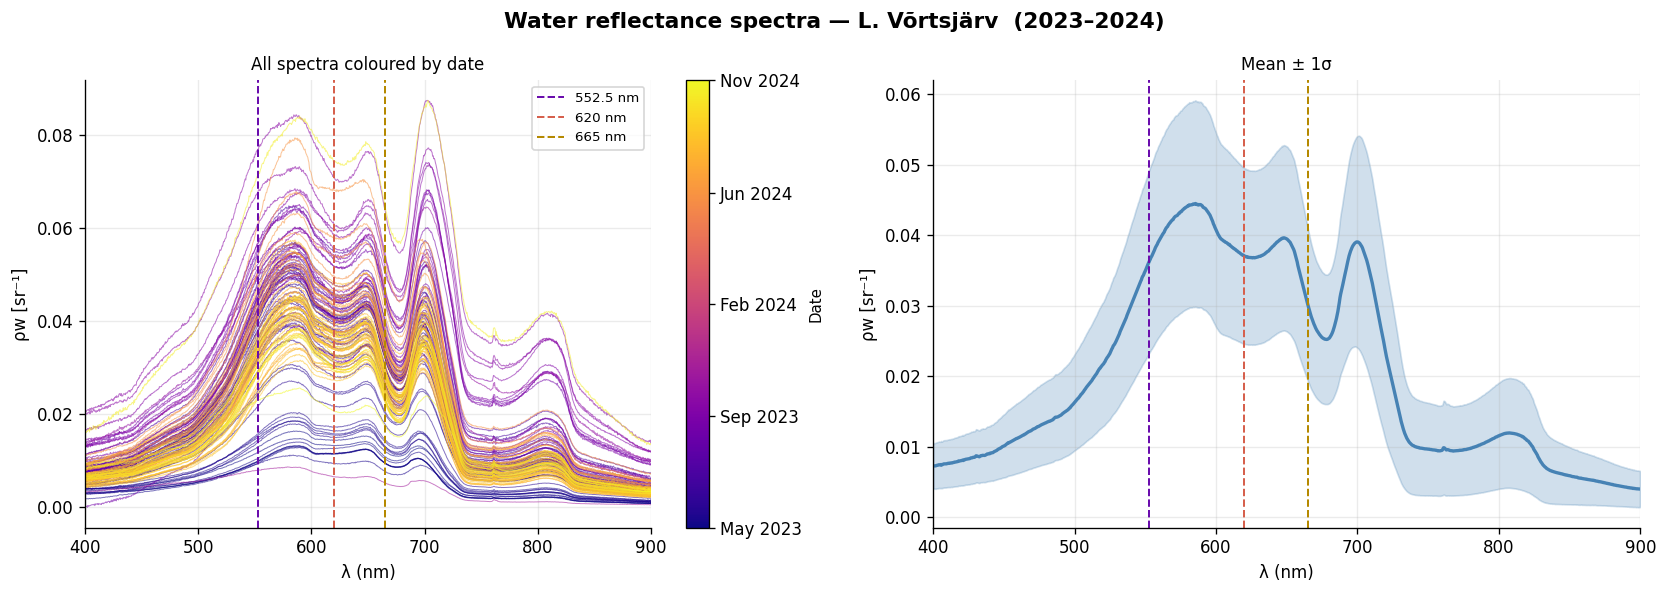

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Water reflectance spectra — {STATION}  ({dates.min().year}–{dates.max().year})',
             fontsize=13, fontweight='bold')

# Left: all spectra coloured by date
ax = axes[0]
cmap = plt.cm.plasma
norm_c = plt.Normalize(vmin=dates.min().toordinal(), vmax=dates.max().toordinal())
mask_wl = (wl >= 400) & (wl <= 900)
for i in range(len(dates)):
    ax.plot(wl[mask_wl], RHOW[i, mask_wl],
            color=cmap(norm_c(dates[i].toordinal())), lw=0.6, alpha=0.55)
# Vertical markers
for lam, lbl, co in [(552.5,'552.5 nm','#6a0dad'),
                      (620,  '620 nm',  '#d6604d'),
                      (665,  '665 nm',  '#b58900')]:
    ax.axvline(lam, color=co, lw=1.2, ls='--', label=lbl)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_c)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax)
tick_dates = pd.date_range(dates.min(), dates.max(), periods=5)
cb.set_ticks([d.toordinal() for d in tick_dates])
cb.set_ticklabels([d.strftime('%b %Y') for d in tick_dates])
cb.set_label('Date', fontsize=9)
ax.set_xlabel('λ (nm)'); ax.set_ylabel('ρw [sr⁻¹]')
ax.set_title('All spectra coloured by date', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(400, 900)

# Right: mean ± std
ax2 = axes[1]
mu  = np.nanmean(RHOW[:, mask_wl], axis=0)
sd  = np.nanstd(RHOW[:, mask_wl],  axis=0)
ax2.fill_between(wl[mask_wl], mu - sd, mu + sd, alpha=0.25, color='steelblue', label='± 1 std')
ax2.plot(wl[mask_wl], mu, color='steelblue', lw=2, label='Mean')
for lam, lbl, co in [(552.5,'552.5 nm','#6a0dad'),
                      (620,  '620 nm',  '#d6604d'),
                      (665,  '665 nm',  '#b58900')]:
    ax2.axvline(lam, color=co, lw=1.2, ls='--', label=lbl)
ax2.set_xlabel('λ (nm)'); ax2.set_ylabel('ρw [sr⁻¹]')
ax2.set_title('Mean ± 1σ', fontsize=10)

ax2.set_xlim(400, 900)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / '08_1_reflectance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Compute D²(λ) for all four normalisation strategies

In [106]:
from scipy.signal import savgol_filter

# ── Pre-smooth RHOW before differentiation ────────────────────────────────────
# Hypstar has finer/noisier spectra than PANTHYR — SG smoothing before D²
# gives much cleaner second derivatives without changing the phytospec call.
# Tune SG_WINDOW: 15 → moderate, 21 → strong. Must be odd.
SG_WINDOW = 21
SG_ORDER  = 3

RHOW_SMOOTH = np.array([
    savgol_filter(RHOW[i], window_length=SG_WINDOW, polyorder=SG_ORDER)
    for i in range(len(dates))
])
print(f'Pre-smoothed RHOW with SG(window={SG_WINDOW}, order={SG_ORDER}) ✓')

Pre-smoothed RHOW with SG(window=21, order=3) ✓


In [107]:
from scipy.ndimage import uniform_filter1d

def compute_D2_raw(rhow_smooth, wl, delta, n_smooth):
    """
    Second derivative of raw (non-normalised) ρw.
    Replicates phytospec's internal scheme: n_smooth passes of 5-pt
    uniform smoothing, then numpy double-gradient with step delta.
    Used only for the 'raw' normalisation case — alg.compute_D2
    always normalises by a reference wavelength and cannot be bypassed.
    """
    spec = rhow_smooth.copy()
    for _ in range(n_smooth):
        spec = uniform_filter1d(spec, size=5)
    return np.gradient(np.gradient(spec, delta), delta)

## Note on smoothing strategy

The Hypstar sensor has Δλ ≈ 0.49 nm vs. 2.5 nm for PANTHYR. 
`alg.compute_D2(n_smooth=2)` applies 2 passes of a 5-point uniform filter 
(Lubac 2008 standard), smoothing over ~2.5 nm on the Hypstar grid. This is 
sufficient to recover the correct D²(552) sign for Cy classification (75–80% 
Cy-negative, consistent with in-situ wet-weight data).

Pre-smoothing with SG(window=21) before compute_D2 was tested but **must not 
be used**: it smooths over ~10 nm additional width and blurs the phycocyanin 
absorption trough at 620 nm, eliminating the negative curvature at 552 nm 
and reducing Cy detection to ~44%.

If smoother D²(λ) spectral profiles are needed for visualization, apply SG 
smoothing ONLY for plotting — never for the classification computation itself.

In [109]:
# Cell 14 — CORRECTED: use RHOW directly, not RHOW_SMOOTH
delta_sensor = float(np.median(np.diff(wl)))
NORM_CONFIGS_PLOT = NORM_CONFIGS   # all four

d2_cubes = {}
d2_552   = {}

for key, norm_wl, label, color in NORM_CONFIGS_PLOT:
    cube, vals = [], []
    for i in range(len(dates)):
        if key == 'raw':
            d2 = compute_D2_raw(RHOW[i], wl, delta_sensor, N_SMOOTH)  # ← RHOW
        else:
            d2 = alg.compute_D2(
                rhow     = RHOW[i],          # ← RHOW
                wl       = wl,
                norm_wl  = norm_wl,
                delta    = delta_sensor,
                n_smooth = N_SMOOTH,
            )
        vals.append(alg.interp_at(wl, d2, TARGET_WL))
        cube.append(d2)

    d2_cubes[key] = np.array(cube)
    d2_552[key]   = np.array(vals)
    n_neg = (d2_552[key] < 0).sum()
    print(f'  {label:35s}  neg: {n_neg}/{len(dates)} ({100*n_neg/len(dates):.0f}%)')

  No normalisation                     neg: 102/128 (80%)
  Norm 442.5 nm  (idx 35)              neg: 96/128 (75%)
  Norm 620 nm  (Lubac 2008)            neg: 97/128 (76%)
  Norm 665 nm  (Testing)               neg: 97/128 (76%)


### Section testing on SMOOTH
RHOW  →  SG(window=21)  →  RHOW_SMOOTH  →  alg.compute_D2(n_smooth=2)
                                                  ↳ applies 2 more uniform_filter passes internally
 
 
 Total smoothing = SG(~10 nm window) + 2 additional passes inside alg.compute_D2. This is too aggressive — it is blurring the narrow phycocyanin-related curvature at 552 nm that D²(552) depends on, converting genuine negative values into near-zero or positive ones.
The original 75% result was almost certainly computed with RHOW directly (no SG pre-smoothing), relying only on alg.compute_D2's internal smoothing. Test this to confirm:                                                 

In [ ]:
# Test 1: no SG pre-smoothing (original behaviour)
for key, norm_wl, label, color in NORM_CONFIGS_PLOT:
    vals = []
    for i in range(len(dates)):
        if key == 'raw':
            d2 = compute_D2_raw(RHOW[i], wl, delta_sensor, N_SMOOTH)  # ← RHOW not RHOW_SMOOTH
        else:
            d2 = alg.compute_D2(
                rhow     = RHOW[i],          # ← RHOW not RHOW_SMOOTH
                wl       = wl,
                norm_wl  = norm_wl,
                delta    = delta_sensor,
                n_smooth = N_SMOOTH,         # internal smoothing only
            )
        vals.append(alg.interp_at(wl, d2, TARGET_WL))
    n_neg = sum(v < 0 for v in vals)
    print(f'{label:35s}  neg: {n_neg}/128 ({100*n_neg/128:.0f}%)')

# Test 2: SG pre-smoothing but disable internal smoothing
for key, norm_wl, label, color in NORM_CONFIGS_PLOT:
    vals = []
    for i in range(len(dates)):
        if key == 'raw':
            d2 = compute_D2_raw(RHOW_SMOOTH[i], wl, delta_sensor, n_smooth=0)  # ← no extra passes
        else:
            d2 = alg.compute_D2(
                rhow     = RHOW_SMOOTH[i],
                wl       = wl,
                norm_wl  = norm_wl,
                delta    = delta_sensor,
                n_smooth = 0,                # ← SG already handled it
            )
        vals.append(alg.interp_at(wl, d2, TARGET_WL))
    n_neg = sum(v < 0 for v in vals)
    print(f'{label:35s}  neg: {n_neg}/128 ({100*n_neg/128:.0f}%)')

## 6. Time series of D²(552) — side-by-side comparison

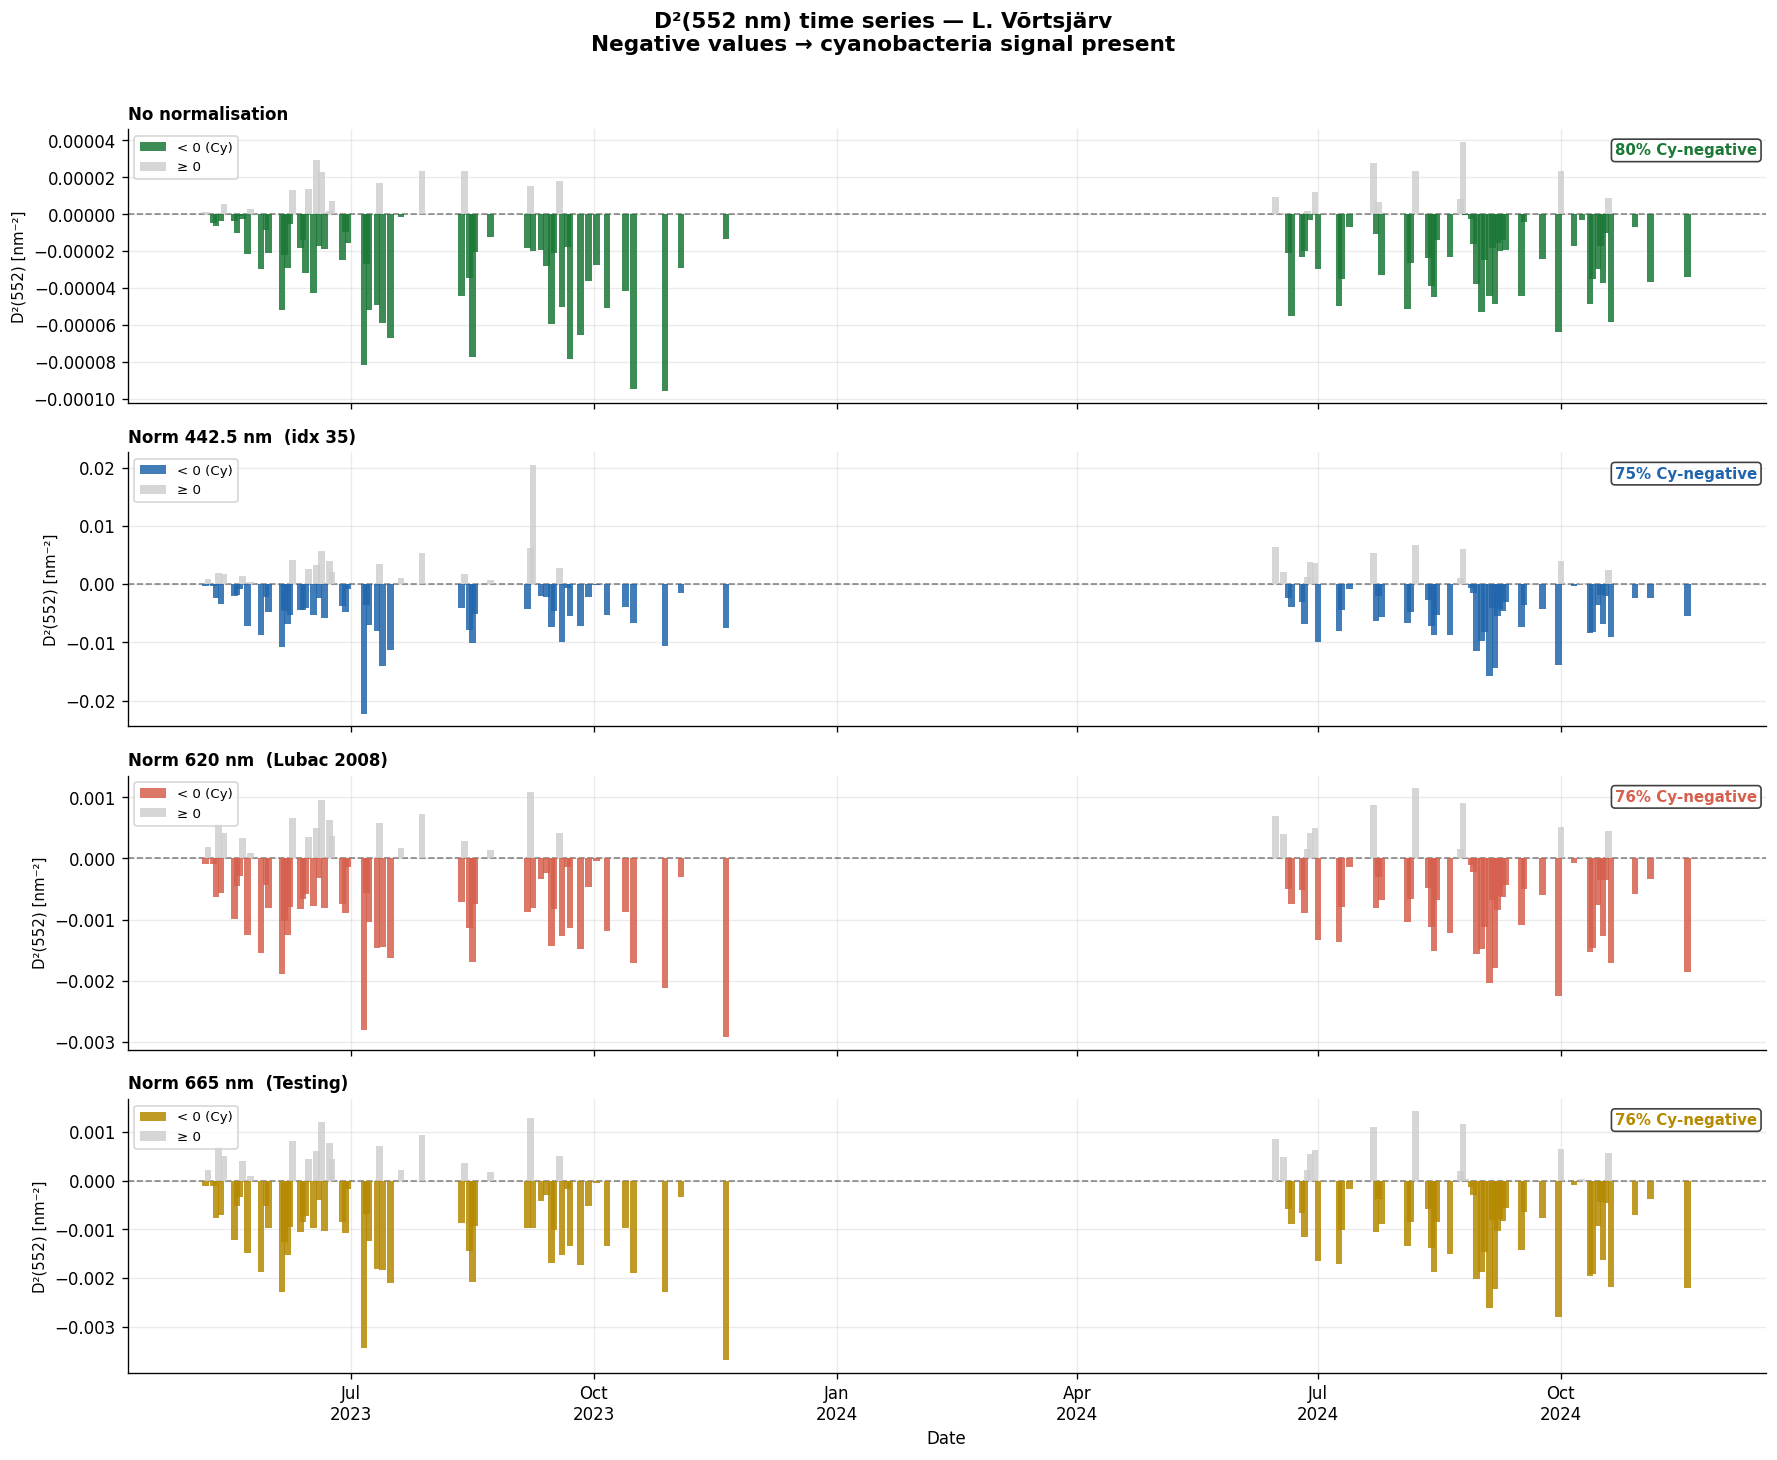

In [110]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fig.suptitle(
    f'D²(552 nm) time series — {STATION}\n'
    'Negative values → cyanobacteria signal present',
    fontsize=13, fontweight='bold', y=1.01
)

for ax, (key, norm_wl, label, color) in zip(axes, NORM_CONFIGS_PLOT ):
    v = d2_552[key]
    neg, pos = v < 0, v >= 0

    ax.axhline(0, color='k', lw=1, ls='--', alpha=0.45, zorder=2)
    ax.bar(dates[neg], v[neg], width=2.5, color=color,    alpha=0.85, label='< 0 (Cy)', zorder=3)
    ax.bar(dates[pos], v[pos], width=2.5, color='#cccccc', alpha=0.8,  label='≥ 0',     zorder=3)

    ax.set_title(label, fontsize=10, loc='left', fontweight='bold')
    ax.set_ylabel('D²(552) [nm⁻²]', fontsize=9)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.8)
    ax.text(0.995, 0.95,
            f'{100*neg.mean():.0f}% Cy-negative',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.75))

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / '08_2_d2_552_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Monthly boxplots — seasonality of D²(552)

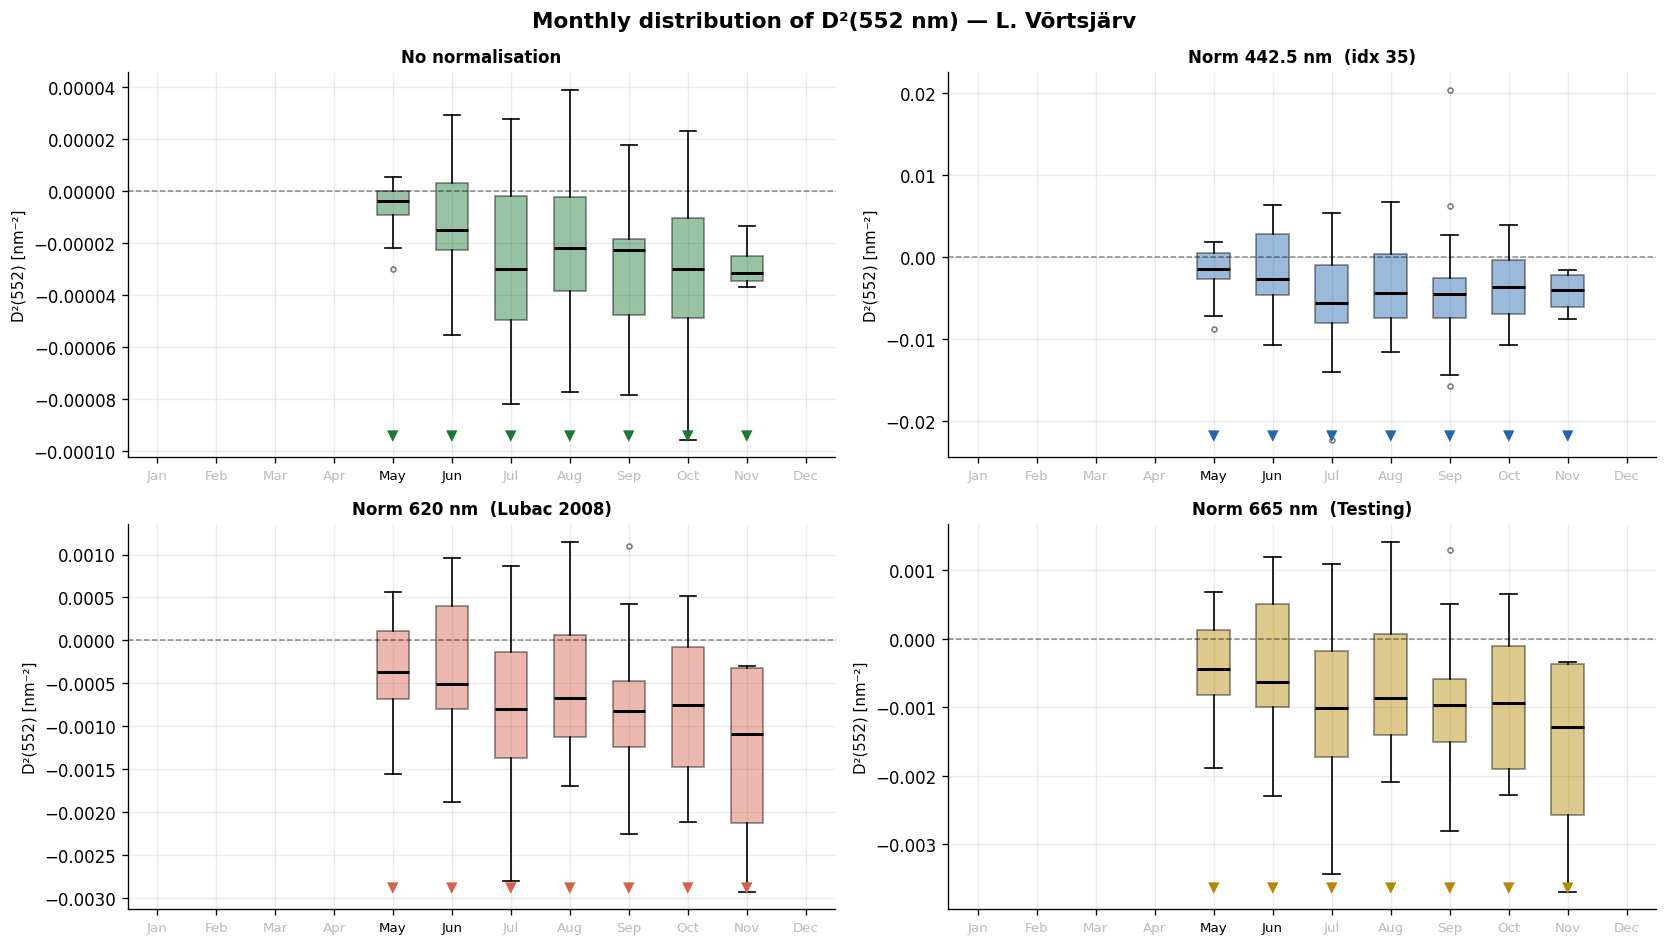

In [111]:
MONTHS       = list(range(1, 13))
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
months_arr   = dates.dt.month.values

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
fig.suptitle(f'Monthly distribution of D²(552 nm) — {STATION}',
             fontsize=13, fontweight='bold')

for ax, (key, norm_wl, label, color) in zip(axes.flat, NORM_CONFIGS_PLOT ):
    data_by_month = [d2_552[key][months_arr == m] for m in MONTHS]
    # Keep only months with ≥ 1 observation
    has_data = [len(x) > 0 for x in data_by_month]
    for tick, has in zip(ax.get_xticklabels(), has_data):
        if not has:
            tick.set_color('#bbbbbb')
    data_filt = [x if len(x) > 0 else [np.nan] for x in data_by_month]
    labels_filt = MONTH_LABELS

    bp = ax.boxplot(
        data_filt,
        tick_labels=labels_filt,
        patch_artist=True, widths=0.55,
        medianprops=dict(color='k', lw=1.8),
        flierprops=dict(marker='o', markersize=3, alpha=0.5),
        whiskerprops=dict(lw=1),
        capprops=dict(lw=1),
    )
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.45)

    ax.axhline(0, color='k', lw=0.9, ls='--', alpha=0.45)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('D²(552) [nm⁻²]', fontsize=9)
    ax.tick_params(axis='x', labelsize=8)

    # Annotate months where median < 0
    for m_idx, (m, x) in enumerate(zip(MONTHS, data_by_month)):
        if len(x) > 0 and np.nanmedian(x) < 0:
            ylo, yhi = ax.get_ylim()
            y_annot = ylo + 0.04 * (yhi - ylo)   # always 4% above the bottom edge
            ax.text(m_idx + 1, y_annot, '▼', ha='center', va='bottom',
                    fontsize=9, color=color)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / '08_3_monthly_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

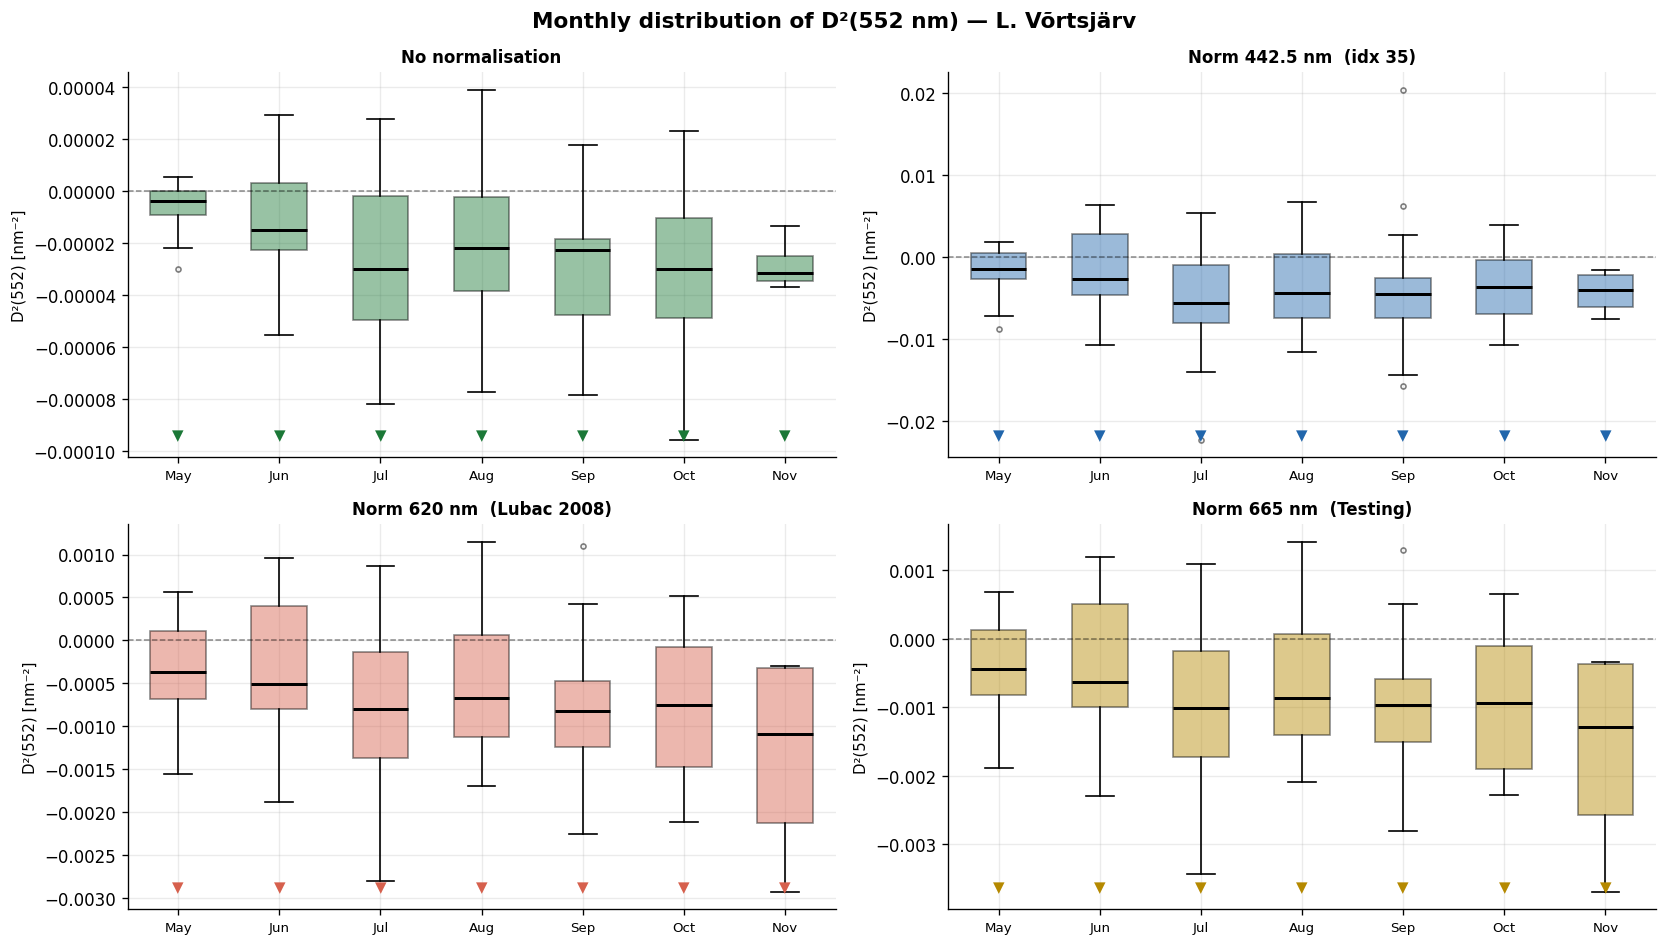

In [112]:
# ── Minimum observations threshold ──────────────────────────────────────────
MIN_OBS = 2   # months with fewer points shown as scatter, not box

months_present = sorted(set(dates.dt.month.values))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
fig.suptitle(f'Monthly distribution of D²(552 nm) — {STATION}',
             fontsize=13, fontweight='bold')

for ax, (key, norm_wl, label, color) in zip(axes.flat, NORM_CONFIGS_PLOT):
    data_by_month  = {m: d2_552[key][months_arr == m] for m in months_present}

    # Split into "enough data" vs single points
    box_months  = [m for m in months_present if len(data_by_month[m]) >= MIN_OBS]
    solo_months = [m for m in months_present if len(data_by_month[m]) == 1]

    box_data    = [data_by_month[m] for m in box_months]
    box_labels  = [MONTH_LABELS[m-1] for m in box_months]
    # Map month → x position (1-indexed into box_months list)
    pos_map     = {m: i+1 for i, m in enumerate(box_months)}

    bp = ax.boxplot(
        box_data,
        positions   = list(range(1, len(box_months)+1)),
        tick_labels = box_labels,
        patch_artist=True, widths=0.55,
        medianprops =dict(color='k', lw=1.8),
        flierprops  =dict(marker='o', markersize=3, alpha=0.5),
        whiskerprops=dict(lw=1),
        capprops    =dict(lw=1),
    )
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.45)

    # ── Single-point months as scatter ──────────────────────────────────────
    for m in solo_months:
        val = data_by_month[m][0]
        # Insert at correct x position relative to box_months
        x_pos = sorted(months_present).index(m) + 1
        ax.scatter(x_pos, val, color=color, s=60, zorder=5,
                   edgecolors='k', linewidths=0.5,
                   label=f'{MONTH_LABELS[m-1]} (n=1)')
        ax.annotate(f'{MONTH_LABELS[m-1]}\n(n=1)',
                    xy=(x_pos, val), xytext=(5, 5),
                    textcoords='offset points', fontsize=7, color='#555555')

    ax.axhline(0, color='k', lw=0.9, ls='--', alpha=0.45)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('D²(552) [nm⁻²]', fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlim(0.5, len(months_present) + 0.5)

    # ── ▼ annotation for months with negative median ─────────────────────────
    ylo, yhi = ax.get_ylim()
    y_annot  = ylo + 0.04 * (yhi - ylo)
    for i, m in enumerate(months_present):
        x = i + 1
        if len(data_by_month[m]) > 0 and np.nanmedian(data_by_month[m]) < 0:
            ax.text(x, y_annot, '▼', ha='center', va='bottom',
                    fontsize=9, color=color)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / '08_3_monthly_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. D²(λ) spectral profiles — all normalisations on same axis

Selected dates spanning the full seasonal range.

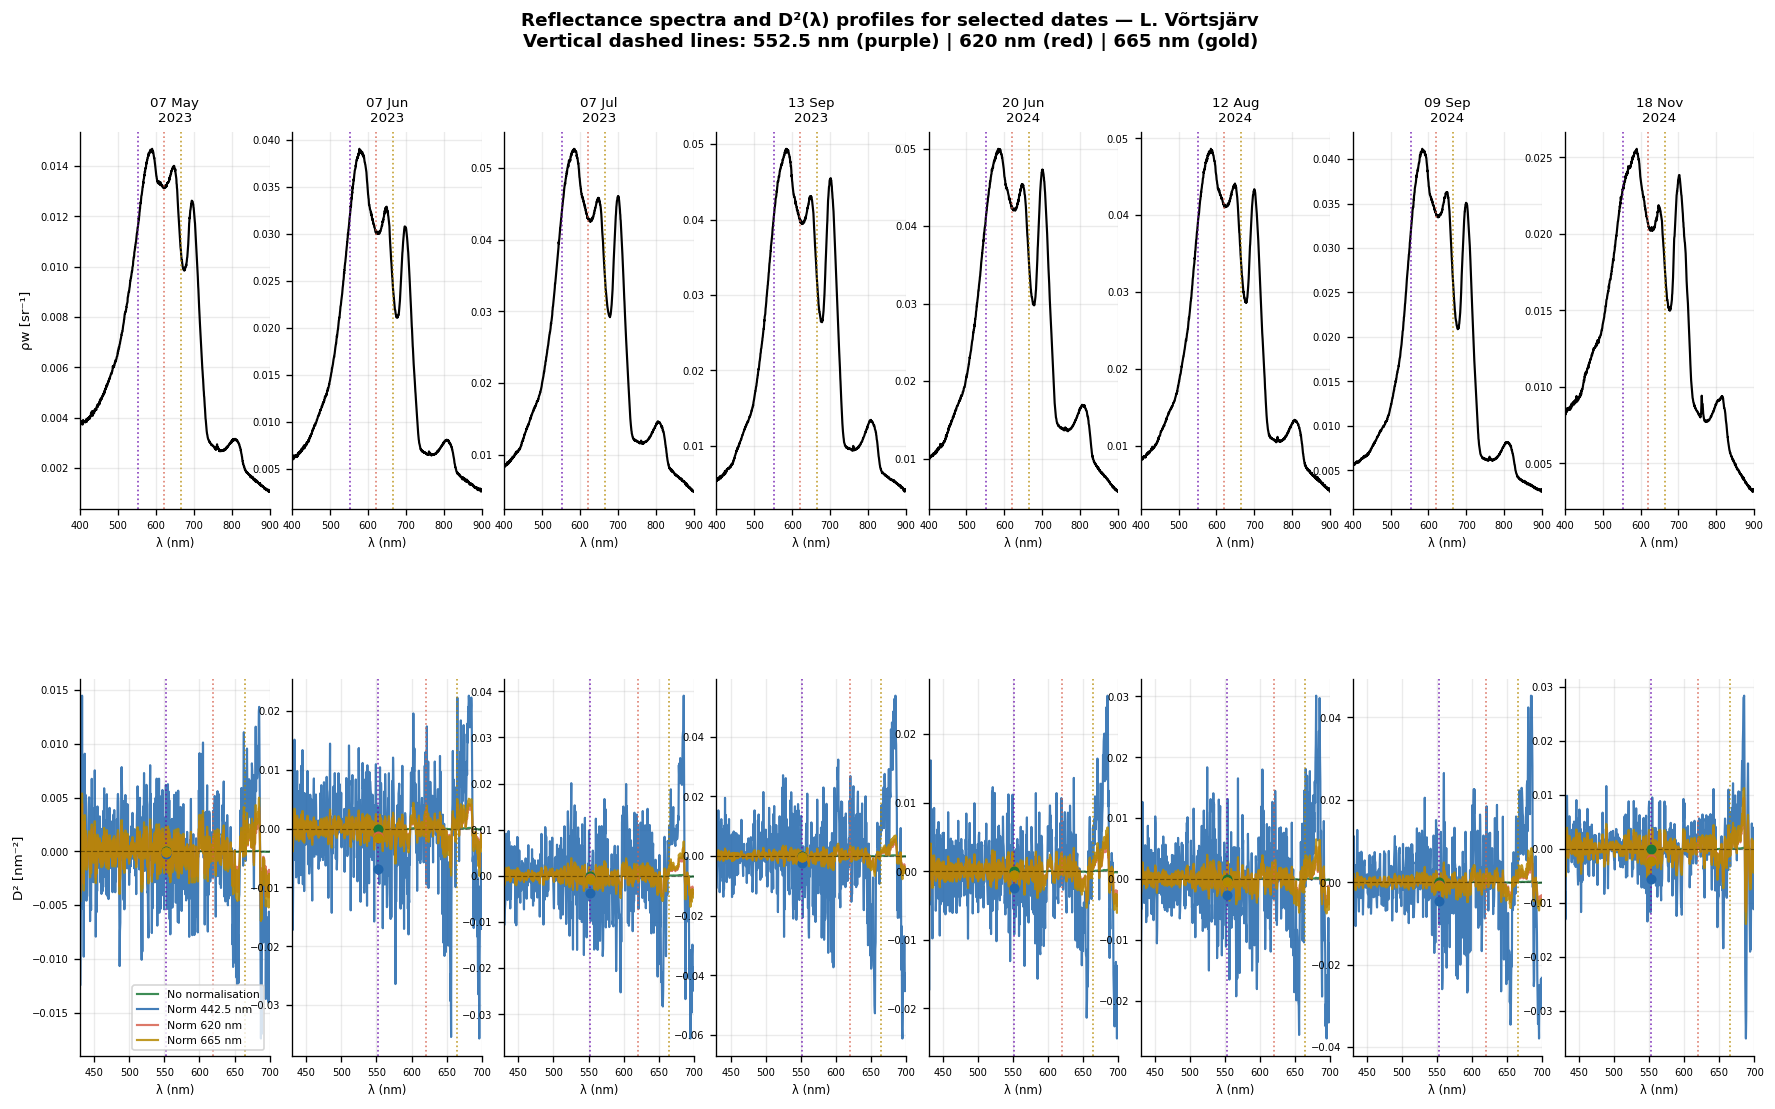

In [113]:
# Select 8 dates evenly spread across the dataset
n_show = 8
sel_idx = np.linspace(0, len(dates) - 1, n_show, dtype=int)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, n_show, hspace=0.45, wspace=0.12)
fig.suptitle(
    f'Reflectance spectra and D²(λ) profiles for selected dates — {STATION}\n'
    'Vertical dashed lines: 552.5 nm (purple) | 620 nm (red) | 665 nm (gold)',
    fontsize=11, fontweight='bold'
)

MARKERS = [(552.5, '#6a0dad'), (620.0, '#d6604d'), (665.0, '#b58900')]

for col, idx in enumerate(sel_idx):
    ax_r = fig.add_subplot(gs[0, col])
    ax_d = fig.add_subplot(gs[1, col])

    rhow_i = RHOW[idx]
    date_s = dates[idx].strftime('%d %b\n%Y')

    # ── Reflectance ──────────────────────────────────────────
    m = (wl >= 400) & (wl <= 900)
    ax_r.plot(wl[m], rhow_i[m], 'k-', lw=1.3)
    for lam, co in MARKERS:
        ax_r.axvline(lam, color=co, lw=1, ls=':', alpha=0.8)
    ax_r.set_title(date_s, fontsize=8)
    ax_r.set_xlabel('λ (nm)', fontsize=7)
    ax_r.tick_params(labelsize=6)
    ax_r.set_xlim(400, 900)
    if col == 0:
        ax_r.set_ylabel('ρw [sr⁻¹]', fontsize=8)

    # ── D² profiles ──────────────────────────────────────────
    m_d = (wl >= 430) & (wl <= 700)
    for key, norm_wl, label, color in NORM_CONFIGS_PLOT :
        d2 = d2_cubes[key][idx]
        lbl = label.split(' (')[0] if col == 0 else None
        ax_d.plot(wl[m_d], d2[m_d], color=color, lw=1.3, label=lbl, alpha=0.85)
    ax_d.axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)
    for lam, co in MARKERS:
        ax_d.axvline(lam, color=co, lw=1, ls=':', alpha=0.8)

    # Dot at 552 for each norm
    for key, norm_wl, label, color in NORM_CONFIGS_PLOT :
        v = d2_552[key][idx]
        ax_d.scatter([TARGET_WL], [v], color=color, s=25, zorder=5)

    ax_d.set_xlabel('λ (nm)', fontsize=7)
    ax_d.tick_params(labelsize=6)
    ax_d.set_xlim(430, 700)
    if col == 0:
        ax_d.set_ylabel('D² [nm⁻²]', fontsize=8)
        ax_d.legend(fontsize=6.5, loc='lower right', framealpha=0.8)

plt.savefig(cfg.FIGURES_DIR / '08_4_d2_spectral_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Cross-normalisation scatter — sign agreement analysis

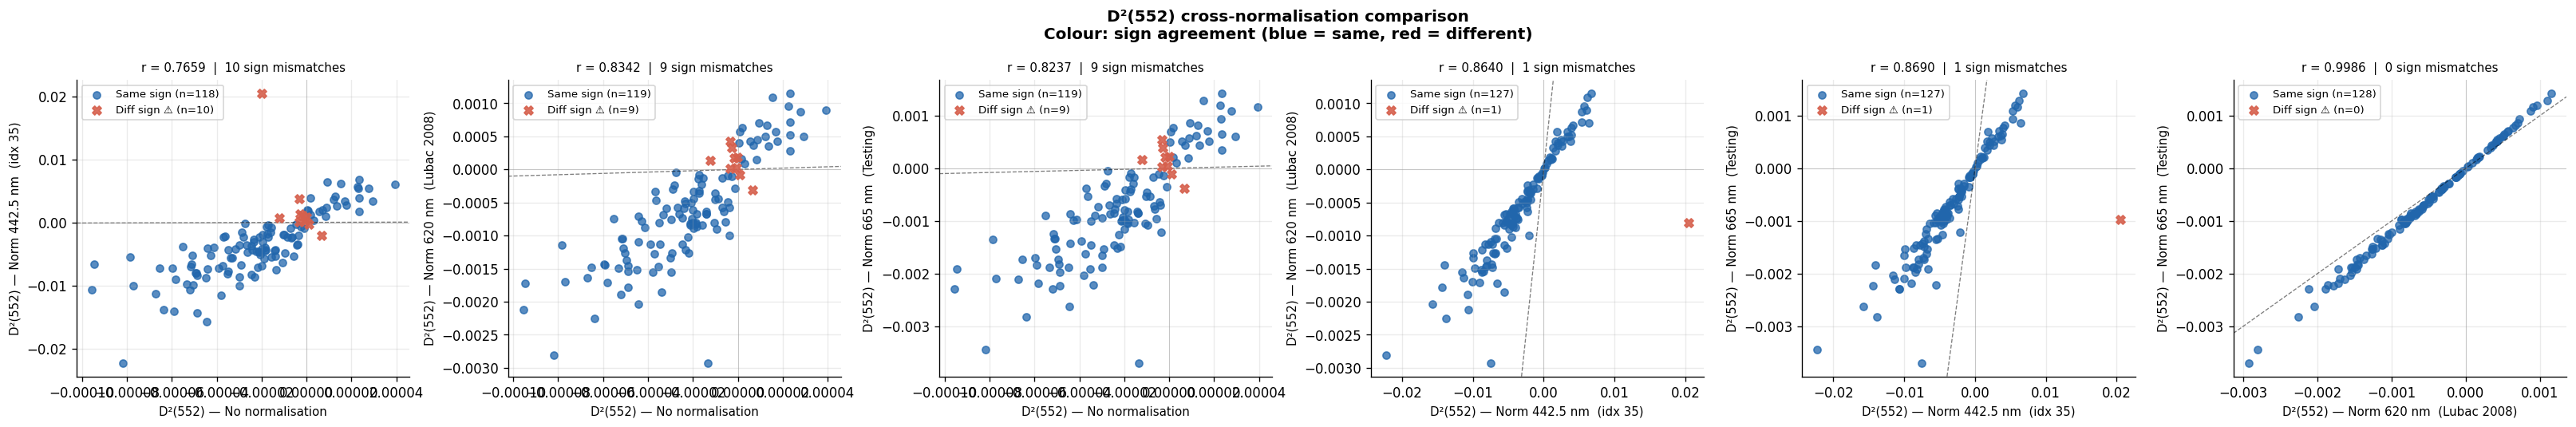

In [114]:
from itertools import combinations

keys = [k for k, *_ in NORM_CONFIGS_PLOT ]
pairs = list(combinations(keys, 2))

fig, axes = plt.subplots(1, len(pairs), figsize=(4.5 * len(pairs), 4.5))
if len(pairs) == 1:
    axes = [axes]
fig.suptitle('D²(552) cross-normalisation comparison\nColour: sign agreement (blue = same, red = different)',
             fontsize=12, fontweight='bold')

for ax, (ka, kb) in zip(axes, pairs):
    xa = d2_552[ka]
    xb = d2_552[kb]
    same = np.sign(xa) == np.sign(xb)
    n_diff = (~same).sum()

    ax.scatter(xa[same],  xb[same],  color='#2166ac', s=30, alpha=0.75, label=f'Same sign (n={same.sum()})')
    ax.scatter(xa[~same], xb[~same], color='#d6604d', s=45, alpha=0.9,
               marker='X', zorder=5, label=f'Diff sign ⚠ (n={n_diff})')

    # 1:1 and zero lines
    lim = np.nanpercentile(np.concatenate([xa, xb]), [1, 99])
    ax.axline((0, 0), slope=1, color='k', ls='--', lw=0.8, alpha=0.5)
    ax.axhline(0, color='gray', lw=0.5, alpha=0.4)
    ax.axvline(0, color='gray', lw=0.5, alpha=0.4)

    # Pearson r
    mask_fin = np.isfinite(xa) & np.isfinite(xb)
    r = np.corrcoef(xa[mask_fin], xb[mask_fin])[0, 1]

    la = NORM_DICT[ka][1]; lb = NORM_DICT[kb][1]
    ax.set_xlabel(f'D²(552) — {la}', fontsize=9)
    ax.set_ylabel(f'D²(552) — {lb}', fontsize=9)
    ax.set_title(f'r = {r:.4f}  |  {n_diff} sign mismatches', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / '08_5_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Extreme cases: strongest and weakest Cy signal

In [115]:
# Use norm 665 as reference to identify extreme dates
ref_key   = '665'
v_ref     = d2_552[ref_key]
idx_cy    = int(np.nanargmin(v_ref))   # most negative = strongest Cy
idx_no    = int(np.nanargmax(v_ref))   # most positive = weakest  Cy

print(f'Strongest Cy signal : {dates[idx_cy].strftime("%d %b %Y")}  D²(552, 665nm) = {v_ref[idx_cy]:+.5f}')
print(f'Weakest   Cy signal : {dates[idx_no].strftime("%d %b %Y")}  D²(552, 665nm) = {v_ref[idx_no]:+.5f}')

print('\nD²(552) values at extreme dates:')
print(f'{"Normalisation":36s}  {"Strong Cy":>12}  {"Weak Cy":>12}')
for key, _, label, _ in NORM_CONFIGS_PLOT :
    print(f'  {label:34s}  {d2_552[key][idx_cy]:12.5f}  {d2_552[key][idx_no]:12.5f}')

Strongest Cy signal : 20 Nov 2023  D²(552, 665nm) = -0.00369
Weakest   Cy signal : 07 Aug 2024  D²(552, 665nm) = +0.00142

D²(552) values at extreme dates:
Normalisation                            Strong Cy       Weak Cy
  No normalisation                        -0.00001       0.00002
  Norm 442.5 nm  (idx 35)                 -0.00754       0.00676
  Norm 620 nm  (Lubac 2008)               -0.00293       0.00115
  Norm 665 nm  (Testing)                  -0.00369       0.00142


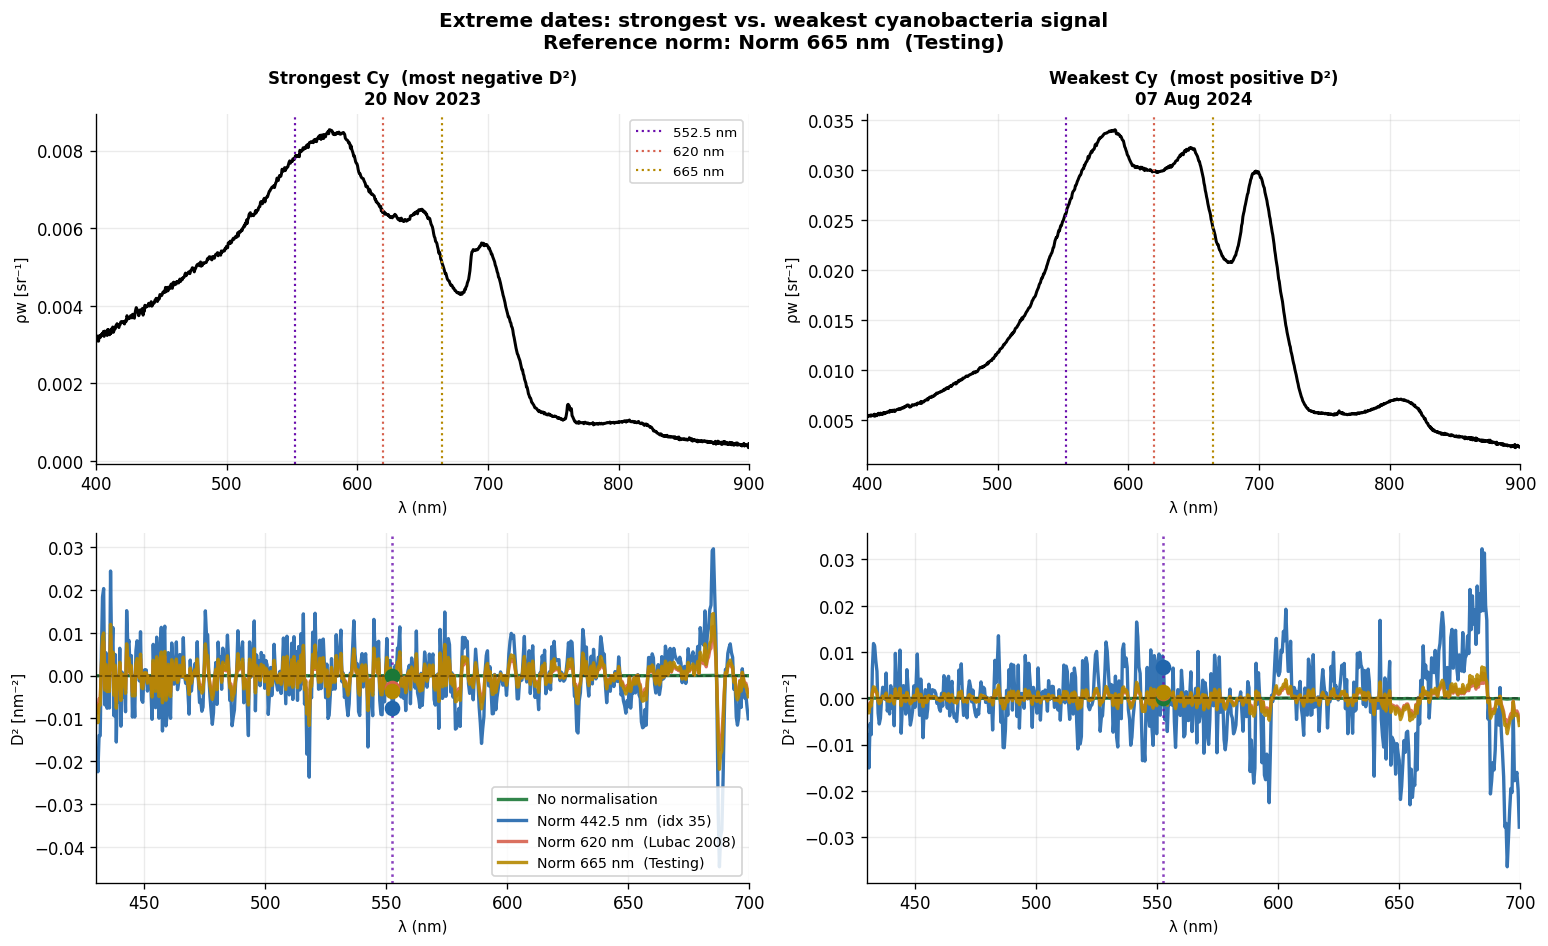

In [116]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Extreme dates: strongest vs. weakest cyanobacteria signal\n'
             f'Reference norm: {NORM_DICT[ref_key][1]}',
             fontsize=12, fontweight='bold')

CASES = [
    (idx_cy, 'Strongest Cy  (most negative D²)'),
    (idx_no, 'Weakest Cy  (most positive D²)'),
]

for col, (idx, case) in enumerate(CASES):
    ax_r, ax_d = axes[0, col], axes[1, col]
    rhow_i = RHOW[idx]
    date_s = dates[idx].strftime('%d %b %Y')

    # ── Reflectance ──────────────────────────────────────────
    m = (wl >= 400) & (wl <= 900)
    ax_r.plot(wl[m], rhow_i[m], 'k-', lw=1.8)
    for lam, co, lbl in [(552.5,'#6a0dad','552.5 nm'), (620,'#d6604d','620 nm'), (665,'#b58900','665 nm')]:
        ax_r.axvline(lam, color=co, lw=1.3, ls=':', label=lbl)
    ax_r.set_title(f'{case}\n{date_s}', fontsize=10, fontweight='bold')
    ax_r.set_xlabel('λ (nm)', fontsize=9)
    ax_r.set_ylabel('ρw [sr⁻¹]', fontsize=9)
    ax_r.set_xlim(400, 900)
    if col == 0:
        ax_r.legend(fontsize=8, loc='upper right', framealpha=0.8)

    # ── D² profiles ──────────────────────────────────────────
    m_d = (wl >= 430) & (wl <= 700)
    for key, norm_wl, label, color in NORM_CONFIGS_PLOT :
        d2 = d2_cubes[key][idx]
        ax_d.plot(wl[m_d], d2[m_d], color=color, lw=2, label=label, alpha=0.9)
        ax_d.scatter([TARGET_WL], [d2_552[key][idx]], color=color, s=70, zorder=6)

    ax_d.axhline(0, color='k', lw=1, ls='--', alpha=0.45)
    ax_d.axvline(TARGET_WL, color='#6a0dad', lw=1.5, ls=':', alpha=0.8)
    ax_d.set_xlabel('λ (nm)', fontsize=9)
    ax_d.set_ylabel('D² [nm⁻²]', fontsize=9)
    ax_d.set_xlim(430, 700)
    if col == 0:
        ax_d.legend(fontsize=8.5, loc='lower right', framealpha=0.85)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / '08_6_extreme_cases.png', dpi=150, bbox_inches='tight')
plt.show()

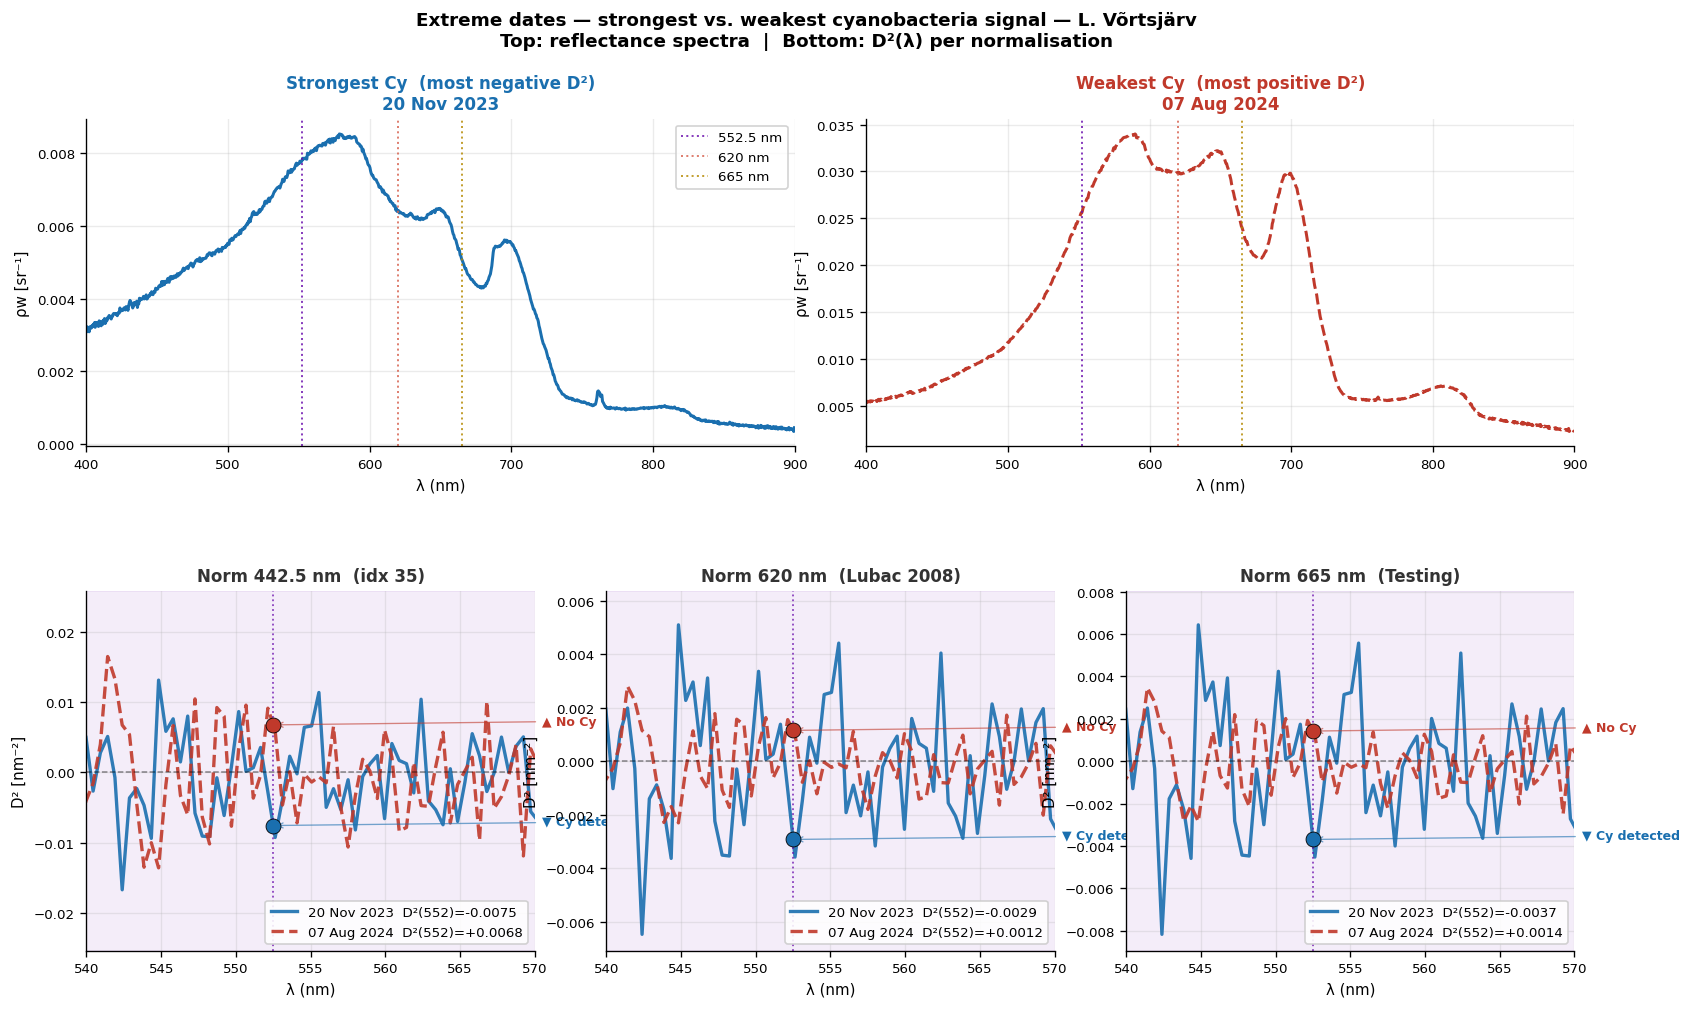

In [120]:
# ── Same extreme dates as cell 21 ─────────────────────────────────────────────
ref_key = '665'
v_ref   = d2_552[ref_key]
idx_cy  = int(np.nanargmin(v_ref))   # strongest Cy
idx_no  = int(np.nanargmax(v_ref))   # weakest Cy

CASES = [
    (idx_cy, 'Strongest Cy  (most negative D²)', '#1a6faf', '-'),   # blue, solid
    (idx_no, 'Weakest Cy  (most positive D²)',   '#c0392b', '--'),   # red,  dashed
]

# 3-norm configs (raw excluded)
#NORM_CONFIGS_PLOT = [c for c in NORM_CONFIGS if c[0] != 'raw']
n_norms = len(NORM_CONFIGS_PLOT)   # 3

# ── GridSpec: 2 rows top (reflectance), 1 row bottom (D² per norm) ────────────
# Use a 6-column grid so top 2 panels each span 3 cols, bottom 3 panels 2 cols each
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(
    2, 6,
    figure=fig,
    hspace=0.42, wspace=0.38,
    height_ratios=[1, 1.1],
)

fig.suptitle(
    f'Extreme dates — strongest vs. weakest cyanobacteria signal — {STATION}\n'
    'Top: reflectance spectra  |  Bottom: D²(λ) per normalisation',
    fontsize=11, fontweight='bold'
)

MARKERS = [(552.5, '#6a0dad', '552.5 nm'),
           (620.0, '#d6604d', '620 nm'),
           (665.0, '#b58900', '665 nm')]

m_r = (wl >= 400) & (wl <= 900)
m_d = (wl >= 520) & (wl <= 680)

# ── Top row: reflectance ──────────────────────────────────────────────────────
for col_span, (idx, case_label, line_color, ls) in enumerate(CASES):
    ax = fig.add_subplot(gs[0, col_span*3 : col_span*3 + 3])
    date_s = dates[idx].strftime('%d %b %Y')

    ax.plot(wl[m_r], RHOW[idx, m_r], color=line_color, lw=1.8, ls=ls)
    for lam, co, lbl in MARKERS:
        ax.axvline(lam, color=co, lw=1.2, ls=':', alpha=0.8,
                   label=lbl if col_span == 0 else None)

    ax.set_title(f'{case_label}\n{date_s}', fontsize=10, fontweight='bold',
                 color=line_color)
    ax.set_xlabel('λ (nm)', fontsize=9)
    ax.set_ylabel('ρw [sr⁻¹]', fontsize=9)
    ax.set_xlim(400, 900)
    ax.tick_params(labelsize=8)
    if col_span == 0:
        ax.legend(fontsize=8, loc='upper right', framealpha=0.85)

# ── Bottom row: one D² panel per normalisation ────────────────────────────────

# Local variable — does NOT touch the global NORM_CONFIGS_PLOT
norm_configs_bottom = [c for c in NORM_CONFIGS_PLOT if c[0] != 'raw']
n_norms = len(norm_configs_bottom)   # 3

# GridSpec stays as 6 columns
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.42, wspace=0.38,
                       height_ratios=[1, 1.1])

# Bottom row loop uses local variable
for n_col, (key, norm_wl, label, norm_color) in enumerate(norm_configs_bottom):

    ax = fig.add_subplot(gs[1, n_col*2 : n_col*2 + 2])

    for idx, case_label, line_color, ls in CASES:
        d2     = d2_cubes[key][idx]
        d2_val = d2_552[key][idx]
        date_s = dates[idx].strftime('%d %b %Y')

        ax.plot(wl[m_d], d2[m_d],
                color=line_color, lw=2.0, ls=ls, alpha=0.9,
                label=f'{date_s}  D²(552)={d2_val:+.4f}')
        ax.scatter([TARGET_WL], [d2_val],
                   color=line_color, s=80, zorder=6,
                   edgecolors='k', linewidths=0.5)

    ax.axhline(0, color='k', lw=0.9, ls='--', alpha=0.45)
    for lam, co, _ in MARKERS:
        ax.axvline(lam, color=co, lw=1.1, ls=':', alpha=0.75)

    # Shade region around 552.5 nm
    ax.axvspan(535, 590, alpha=0.07, color='#6a0dad', zorder=0)

    ax.set_title(label, fontsize=10, fontweight='bold', color='#333333')
    ax.set_xlabel('λ (nm)', fontsize=9)
    ax.set_ylabel('D² [nm⁻²]', fontsize=9)
    ax.set_xlim(540, 570) #(500, 800)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.88)

    # Annotate sign at 552.5 nm
    for idx, _, line_color, _ in CASES:
        v = d2_552[key][idx]
        sign_str = '▼ Cy detected' if v < 0 else '▲ No Cy'
        ax.annotate(sign_str,
                    xy=(TARGET_WL, v),
                    xytext=(TARGET_WL + 18, v),
                    fontsize=7.5, color=line_color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=line_color,
                                   lw=0.8, alpha=0.6))

plt.savefig(cfg.FIGURES_DIR / '08_6_extreme_cases_per_norm.png', dpi=150, bbox_inches='tight')
plt.show()

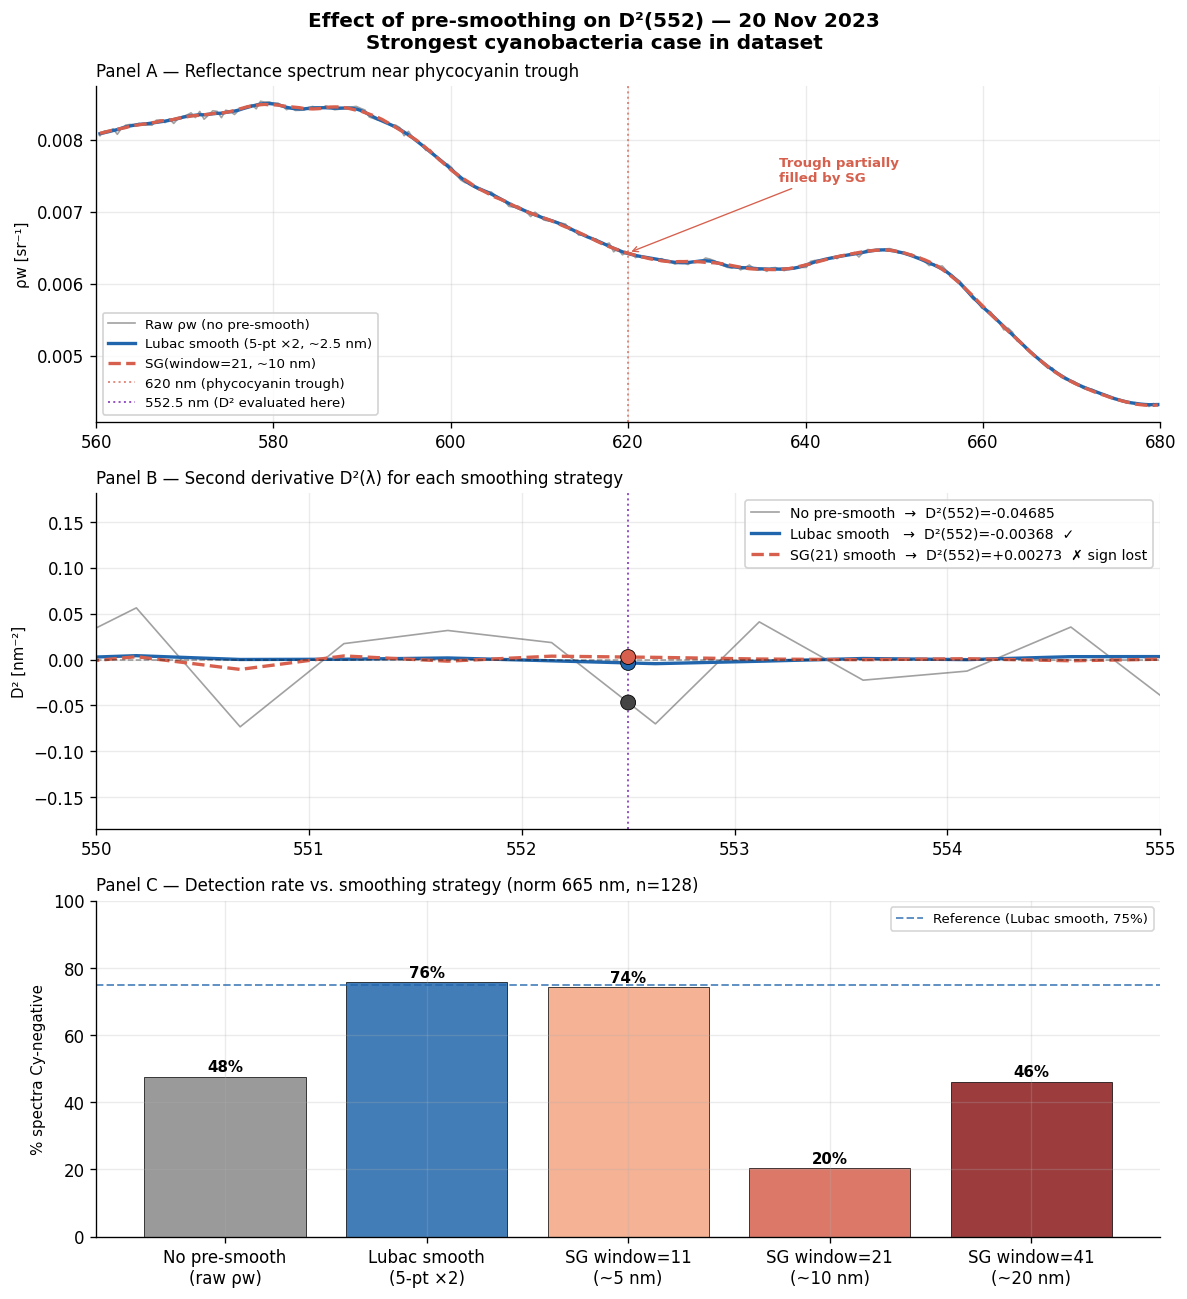

In [127]:
# ── Figure: Smoothing sensitivity — for Kersti ────────────────────────────────
from scipy.signal import savgol_filter
from scipy.ndimage import uniform_filter1d

# Pick the strongest Cy date as example
idx_ex = int(np.nanargmin(d2_552['665']))

# Three input variants
rhow_raw    = RHOW[idx_ex].copy()

def apply_lubac_smooth(spec, n=2):
    """2 passes 5-pt uniform filter — Lubac 2008 standard (inside alg.compute_D2)"""
    for _ in range(n):
        spec = uniform_filter1d(spec, size=5)
    return spec

rhow_lubac  = apply_lubac_smooth(rhow_raw.copy(), n=2)      # correct
rhow_sg21   = savgol_filter(rhow_raw, window_length=21, polyorder=3)  # over-smoothed

# Compute D² for each using norm 665
def get_d2(rhow_in):
    return alg.compute_D2(rhow=rhow_in, wl=wl,
                          norm_wl=665.0, delta=delta_sensor, n_smooth=0)

d2_raw_in   = get_d2(rhow_raw)
d2_lubac_in = get_d2(rhow_lubac)
d2_sg21_in  = get_d2(savgol_filter(rhow_raw, window_length=21, polyorder=3))

val_raw   = alg.interp_at(wl, d2_raw_in,   TARGET_WL)
val_lubac = alg.interp_at(wl, d2_lubac_in, TARGET_WL)
val_sg21  = alg.interp_at(wl, d2_sg21_in,  TARGET_WL)

# ── Layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 11))
fig.suptitle(
    f'Effect of pre-smoothing on D²(552) — {dates[idx_ex].strftime("%d %b %Y")}\n'
    f'Strongest cyanobacteria case in dataset',
    fontsize=12, fontweight='bold'
)

m_zoom = (wl >= 560) & (wl <= 680)   # zoom around phycocyanin trough

# ── Panel A: Reflectance near 620 nm ─────────────────────────────────────────
ax = axes[0]
ax.plot(wl[m_zoom], rhow_raw[m_zoom],   color='#444', lw=1.0, alpha=0.5, label='Raw ρw (no pre-smooth)')
ax.plot(wl[m_zoom], rhow_lubac[m_zoom], color='#2166ac', lw=2.0, label='Lubac smooth (5-pt ×2, ~2.5 nm)')
ax.plot(wl[m_zoom], rhow_sg21[m_zoom],  color='#d6604d', lw=2.0, ls='--', label='SG(window=21, ~10 nm)')
ax.axvline(620, color='#d6604d', lw=1.2, ls=':', alpha=0.7, label='620 nm (phycocyanin trough)')
ax.axvline(TARGET_WL, color='#6a0dad', lw=1.2, ls=':', alpha=0.7, label='552.5 nm (D² evaluated here)')

# Annotate the trough filling
ax.annotate('Trough partially\nfilled by SG',
            xy=(620, rhow_sg21[np.argmin(np.abs(wl - 620))]),
            xytext=(637, rhow_sg21[np.argmin(np.abs(wl - 620))] + 0.001),
            fontsize=8, color='#d6604d', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d6604d', lw=0.8))

ax.set_ylabel('ρw [sr⁻¹]', fontsize=9)
ax.set_title('Panel A — Reflectance spectrum near phycocyanin trough', fontsize=10, loc='left')
ax.legend(fontsize=8, framealpha=0.85)
ax.set_xlim(560, 680)

# ── Panel B: D²(λ) profiles ───────────────────────────────────────────────────
ax = axes[1]
m_d2 = (wl >= 520) & (wl <= 680)
ax.plot(wl[m_d2], d2_raw_in[m_d2],   color='#444', lw=1.0, alpha=0.5, label=f'No pre-smooth  →  D²(552)={val_raw:+.5f}')
ax.plot(wl[m_d2], d2_lubac_in[m_d2], color='#2166ac', lw=2.0, label=f'Lubac smooth   →  D²(552)={val_lubac:+.5f}  ✓')
ax.plot(wl[m_d2], d2_sg21_in[m_d2],  color='#d6604d', lw=2.0, ls='--', label=f'SG(21) smooth  →  D²(552)={val_sg21:+.5f}  {"✓" if val_sg21 < 0 else "✗ sign lost"}')

ax.axhline(0, color='k', lw=0.9, ls='--', alpha=0.4)
ax.axvline(TARGET_WL, color='#6a0dad', lw=1.2, ls=':', alpha=0.7)
ax.scatter([TARGET_WL]*3, [val_raw, val_lubac, val_sg21],
           color=['#444', '#2166ac', '#d6604d'], s=80, zorder=6, edgecolors='k', lw=0.5)

ax.set_ylabel('D² [nm⁻²]', fontsize=9)
ax.set_title('Panel B — Second derivative D²(λ) for each smoothing strategy', fontsize=10, loc='left')
ax.legend(fontsize=8.5, framealpha=0.85)
ax.set_xlim(550, 555)

# ── Panel C: Detection rates comparison ───────────────────────────────────────
ax = axes[2]

# Recompute d2_552 for each smoothing strategy across full dataset (norm 665 only)
pcts = {}
for label_s, smooth_fn in [
    ('No pre-smooth\n(raw ρw)', lambda r: r),
    ('Lubac smooth\n(5-pt ×2)', lambda r: apply_lubac_smooth(r.copy(), n=2)),
    ('SG window=11\n(~5 nm)',   lambda r: savgol_filter(r, 11, 3)),
    ('SG window=21\n(~10 nm)',  lambda r: savgol_filter(r, 21, 3)),
    ('SG window=41\n(~20 nm)',  lambda r: savgol_filter(r, 41, 3)),
]:
    vals = [alg.interp_at(wl,
                alg.compute_D2(rhow=smooth_fn(RHOW[i].copy()), wl=wl,
                               norm_wl=665.0, delta=delta_sensor, n_smooth=0),
                TARGET_WL)
            for i in range(len(dates))]
    pcts[label_s] = 100 * sum(v < 0 for v in vals) / len(vals)

colors_bar = ['#888', '#2166ac', '#f4a582', '#d6604d', '#8b1a1a']
bars = ax.bar(list(pcts.keys()), list(pcts.values()),
              color=colors_bar, alpha=0.85, edgecolor='k', linewidth=0.5)
ax.axhline(75, color='#2166ac', lw=1.2, ls='--', alpha=0.7, label='Reference (Lubac smooth, 75%)')
ax.set_ylabel('% spectra Cy-negative', fontsize=9)
ax.set_ylim(0, 100)
ax.set_title('Panel C — Detection rate vs. smoothing strategy (norm 665 nm, n=128)', fontsize=10, loc='left')
ax.legend(fontsize=8)

for bar, val in zip(bars, pcts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / '08_8_smoothing_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Dynamic range and sensitivity comparison

Compare how well each normalisation **separates** negative from positive D²(552).

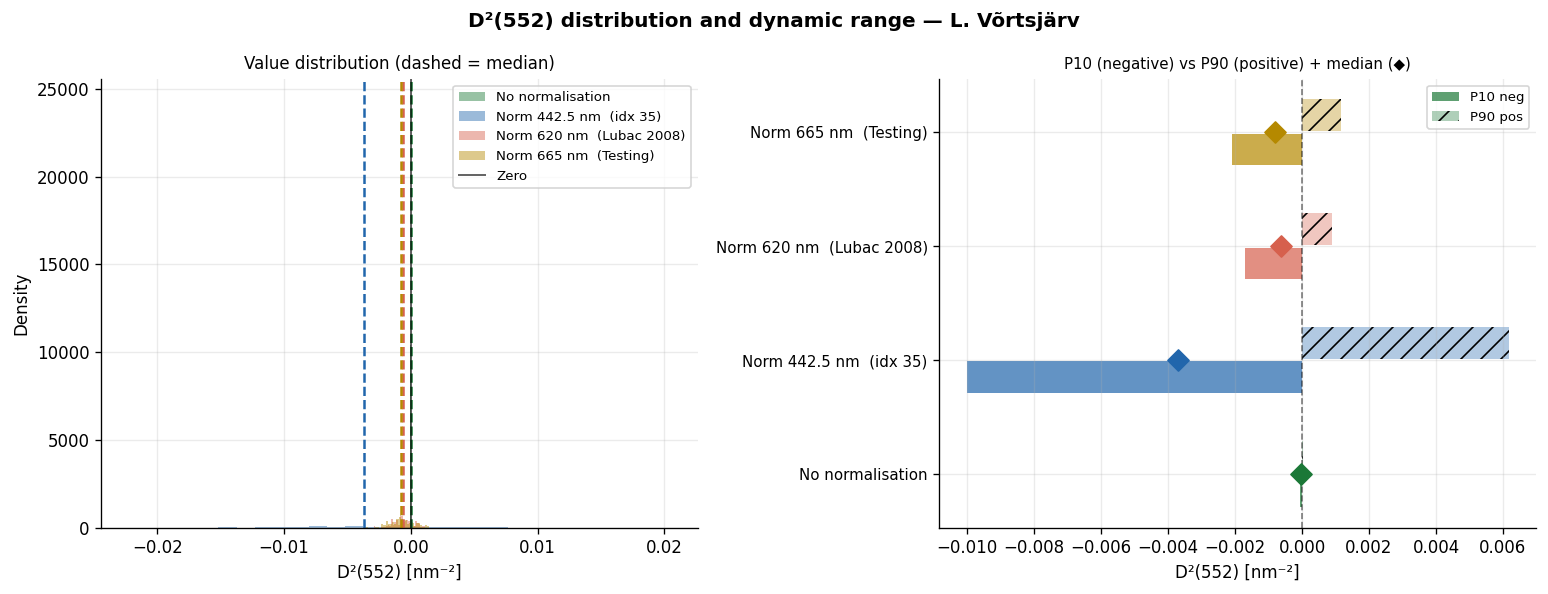

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'D²(552) distribution and dynamic range — {STATION}',
             fontsize=12, fontweight='bold')

# ── Left: KDE / histogram per normalisation ─────────────────────────────────
ax = axes[0]
for key, norm_wl, label, color in NORM_CONFIGS_PLOT :
    v = d2_552[key]
    v_finite = v[np.isfinite(v)]
    ax.hist(v_finite, bins=30, color=color, alpha=0.45, density=True,
            label=label, histtype='stepfilled')
    ax.axvline(np.nanmedian(v), color=color, lw=1.5, ls='--')
ax.axvline(0, color='k', lw=1.2, ls='-', alpha=0.6, label='Zero')
ax.set_xlabel('D²(552) [nm⁻²]', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Value distribution (dashed = median)', fontsize=10)
ax.legend(fontsize=8, framealpha=0.8)

# ── Right: dynamic range bars ─────────────────────────────────────────────────
ax2 = axes[1]
labels_plot = [lbl for _, _, lbl, _ in NORM_CONFIGS_PLOT ]
colors_plot = [col for _, _, _, col in NORM_CONFIGS_PLOT ]
keys_plot   = [k for k, *_ in NORM_CONFIGS_PLOT ]

for i, (key, color) in enumerate(zip(keys_plot, colors_plot)):
    v = d2_552[key]
    v_neg = v[v < 0]
    v_pos = v[v >= 0]
    q_neg = np.nanpercentile(v_neg, 10) if len(v_neg) > 0 else 0
    q_pos = np.nanpercentile(v_pos, 90) if len(v_pos) > 0 else 0
    med   = np.nanmedian(v)
    ax2.barh(i - 0.15, q_neg, color=color, alpha=0.7, height=0.28, label='P10 neg' if i==0 else None)
    ax2.barh(i + 0.15, q_pos, color=color, alpha=0.35, height=0.28, hatch='//', label='P90 pos' if i==0 else None)
    ax2.scatter(med, i, color=color, s=80, zorder=5, marker='D')

ax2.axvline(0, color='k', lw=1, ls='--', alpha=0.5)
ax2.set_yticks(range(len(keys_plot)))
ax2.set_yticklabels(labels_plot, fontsize=9)
ax2.set_xlabel('D²(552) [nm⁻²]', fontsize=10)
ax2.set_title('P10 (negative) vs P90 (positive) + median (◆)', fontsize=9)
ax2.legend(fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / '08_7_dynamic_range.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary statistics table

In [50]:
import pandas as pd

rows = []
for key, norm_wl, label, color in NORM_CONFIGS_PLOT :
    v = d2_552[key]
    n_neg = (v < 0).sum()
    n_pos = (v >= 0).sum()
    # Sign agreement vs. raw (no-norm)
    agree = (np.sign(v) == np.sign(d2_552['raw'])).mean()
    rows.append({
        'Normalisation':     label,
        'n_spectra':         len(v),
        'n_neg (Cy)':        n_neg,
        '% neg':             f'{100*n_neg/len(v):.1f}%',
        'min':               f'{np.nanmin(v):.5f}',
        'median':            f'{np.nanmedian(v):+.5f}',
        'max':               f'{np.nanmax(v):.5f}',
        'IQR':               f'{np.nanpercentile(v,75)-np.nanpercentile(v,25):.5f}',
        'sign agree (vs raw)': f'{agree:.1%}',
    })

summary = pd.DataFrame(rows).set_index('Normalisation')

print('\n── Summary table ────────────────────────────────────────────────────────────')
print(summary.to_string())

# Sign agreement matrix
print('\n── Sign agreement matrix ────────────────────────────────────────────────────')
header = '  '.join(f'{k:5s}' for k, *_ in NORM_CONFIGS_PLOT )
print(f'       {header}')
for ka, *_ in NORM_CONFIGS_PLOT :
    row = '  '.join(
        f'{(np.sign(d2_552[ka]) == np.sign(d2_552[kb])).mean():.2f}'
        for kb, *_ in NORM_CONFIGS_PLOT 
    )
    print(f'{ka:6s} {row}')


── Summary table ────────────────────────────────────────────────────────────
                           n_spectra  n_neg (Cy)  % neg       min    median      max      IQR sign agree (vs raw)
Normalisation                                                                                                    
Norm 442.5 nm  (idx 35)          128          56  43.8%  -0.00369  +0.00027  0.01620  0.00189               93.8%
Norm 620 nm  (Lubac 2008)        128          57  44.5%  -0.00065  +0.00004  0.00077  0.00031               94.5%
Norm 665 nm  (Testing)           128          57  44.5%  -0.00083  +0.00005  0.00093  0.00038               94.5%

── Sign agreement matrix ────────────────────────────────────────────────────
       442    620    665  
442    1.00  0.99  0.99
620    0.99  1.00  1.00
665    0.99  1.00  1.00


## Testing Smoothing

In [51]:
from scipy.signal import savgol_filter

# ── Pre-smooth RHOW before differentiation ────────────────────────────────────
# Hypstar has finer/noisier spectra than PANTHYR — SG smoothing before D²
# gives much cleaner second derivatives without changing the phytospec call.
# Tune SG_WINDOW: 15 → moderate, 21 → strong. Must be odd.
SG_WINDOW = 21
SG_ORDER  = 3

RHOW_SMOOTH = np.array([
    savgol_filter(RHOW[i], window_length=SG_WINDOW, polyorder=SG_ORDER)
    for i in range(len(dates))
])
print(f'Pre-smoothed RHOW with SG(window={SG_WINDOW}, order={SG_ORDER}) ✓')

Pre-smoothed RHOW with SG(window=21, order=3) ✓


In [118]:
# Drop 'raw' — norm_wl='raw' string is not a valid alg.compute_D2 argument
# at this station. Keep only the three meaningful normalizations.
#NORM_CONFIGS_PLOT = [cfg for cfg in NORM_CONFIGS if cfg[0] != 'raw']

delta_sensor = float(np.median(np.diff(wl)))

d2_cubes = {}
d2_552   = {}

for key, norm_wl, label, color in NORM_CONFIGS_PLOT:
    cube, vals = [], []
    for i in range(len(dates)):
        d2 = alg.compute_D2(
            rhow    = RHOW_SMOOTH[i],   # ← smoothed input
            wl      = wl,
            norm_wl = norm_wl,
            delta   = delta_sensor,
            n_smooth = N_SMOOTH ,        #N_SMOOTH additional passes on top of SG
        )
        vals.append(alg.interp_at(wl, d2, TARGET_WL))
        cube.append(d2)
    d2_cubes[key] = np.array(cube)
    d2_552[key]   = np.array(vals)
    n_neg = (d2_552[key] < 0).sum()
    print(f'  {label:35s}  neg: {n_neg}/{len(dates)} ({100*n_neg/len(dates):.0f}%)')

  Norm 442.5 nm  (idx 35)              neg: 56/128 (44%)
  Norm 620 nm  (Lubac 2008)            neg: 57/128 (45%)
  Norm 665 nm  (Testing)               neg: 57/128 (45%)


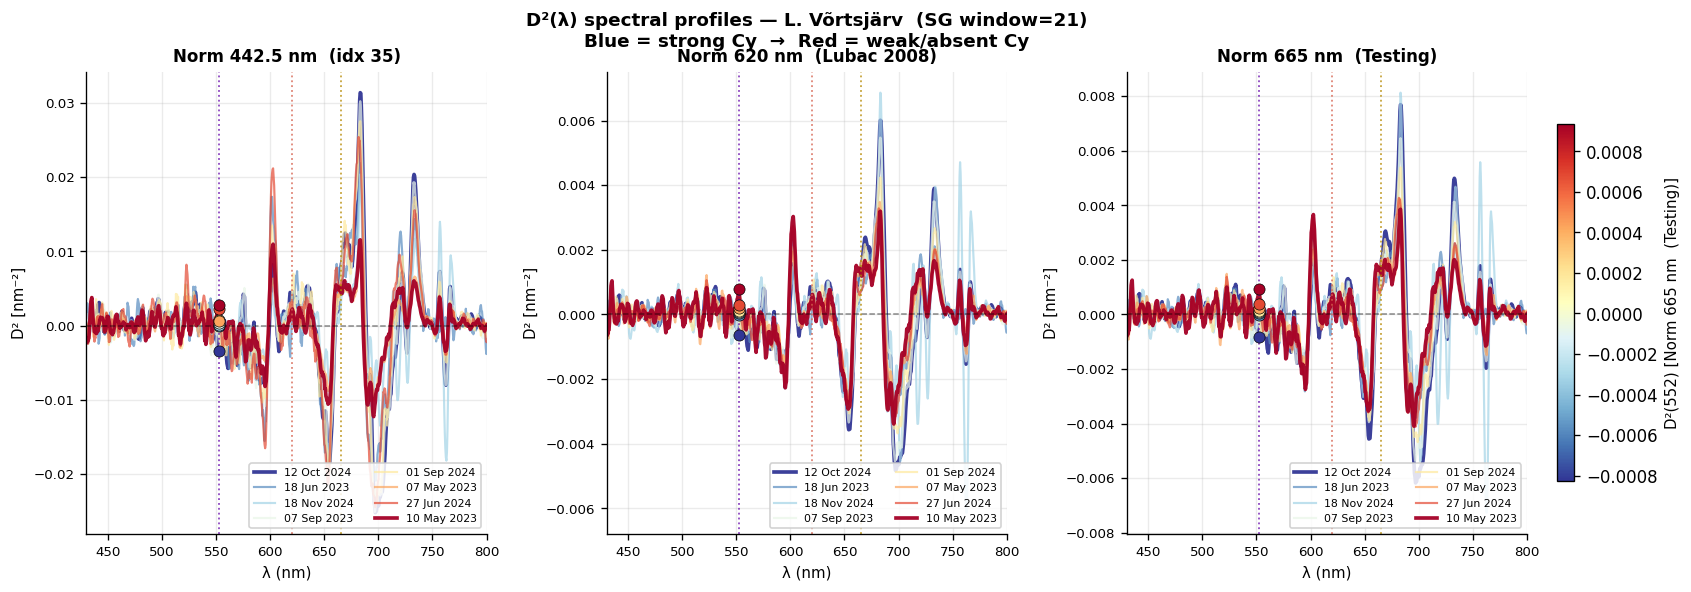

In [52]:
ref_key = '665'
v_ref   = d2_552[ref_key]
idx_cy  = int(np.nanargmin(v_ref))
idx_no  = int(np.nanargmax(v_ref))
pool    = [i for i in range(len(dates)) if i not in (idx_cy, idx_no)]
extra   = [pool[j] for j in np.linspace(0, len(pool)-1, 6, dtype=int)]
sel_idx = sorted(set([idx_cy, idx_no] + extra))

cmap_sel  = plt.cm.RdYlBu_r
ranked    = sorted(sel_idx, key=lambda i: v_ref[i])
rank_norm = {idx: r / (len(ranked)-1) for r, idx in enumerate(ranked)}

# ── 1×3 layout — one panel per normalisation ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5),
                          gridspec_kw={'wspace': 0.30})
fig.suptitle(
    f'D²(λ) spectral profiles — {STATION}  (SG window={SG_WINDOW})\n'
    'Blue = strong Cy  →  Red = weak/absent Cy',
    fontsize=11, fontweight='bold'
)

m_d     = (wl >= 430) & (wl <= 900)
MARKERS = [(552.5, '#6a0dad'), (620.0, '#d6604d'), (665.0, '#b58900')]

for ax, (key, norm_wl, label, color) in zip(axes, NORM_CONFIGS_PLOT):
    for idx in ranked:
        c   = cmap_sel(rank_norm[idx])
        d2  = d2_cubes[key][idx]
        lw  = 2.2 if idx in (idx_cy, idx_no) else 1.3
        alp = 0.95 if idx in (idx_cy, idx_no) else 0.70
        ax.plot(wl[m_d], d2[m_d], color=c, lw=lw, alpha=alp,
                label=dates[idx].strftime('%d %b %Y'))
        ax.scatter([TARGET_WL], [d2_552[key][idx]], color=c, s=45,
                   zorder=6, edgecolors='k', linewidths=0.4)

    ax.axhline(0, color='k', lw=0.9, ls='--', alpha=0.45)
    for lam, co in MARKERS:
        ax.axvline(lam, color=co, lw=1.1, ls=':', alpha=0.75)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('λ (nm)', fontsize=9)
    ax.set_ylabel('D² [nm⁻²]', fontsize=9)
    ax.set_xlim(430, 800)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=6.5, loc='lower right', framealpha=0.85, ncol=2)

sm = plt.cm.ScalarMappable(cmap=cmap_sel,
     norm=plt.Normalize(vmin=v_ref[idx_cy], vmax=v_ref[idx_no]))
sm.set_array([])
cb = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.012, pad=0.02)
cb.set_label(f'D²(552) [{NORM_DICT[ref_key][1]}]', fontsize=9)

plt.savefig(cfg.FIGURES_DIR / '08_4_d2_spectral_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

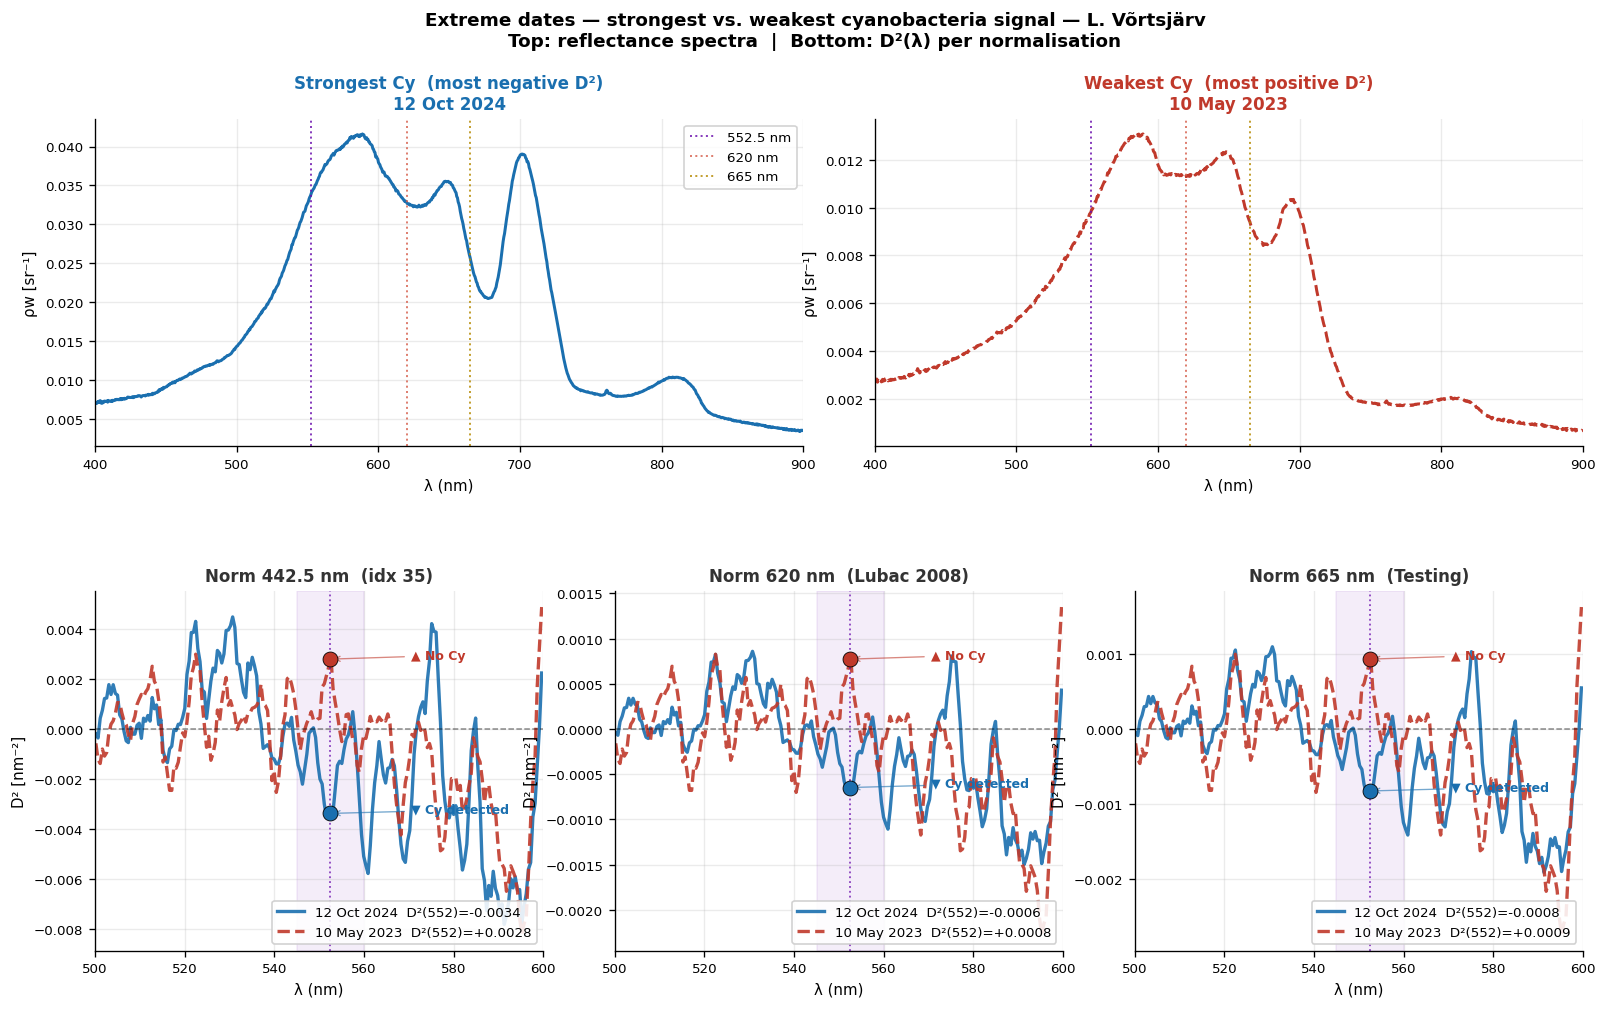

In [53]:
# ── Same extreme dates as cell 21 ─────────────────────────────────────────────
ref_key = '665'
v_ref   = d2_552[ref_key]
idx_cy  = int(np.nanargmin(v_ref))   # strongest Cy
idx_no  = int(np.nanargmax(v_ref))   # weakest Cy

CASES = [
    (idx_cy, 'Strongest Cy  (most negative D²)', '#1a6faf', '-'),   # blue, solid
    (idx_no, 'Weakest Cy  (most positive D²)',   '#c0392b', '--'),   # red,  dashed
]

# 3-norm configs (raw excluded)
NORM_CONFIGS_PLOT = [c for c in NORM_CONFIGS if c[0] != 'raw']
n_norms = len(NORM_CONFIGS_PLOT)   # 3

# ── GridSpec: 2 rows top (reflectance), 1 row bottom (D² per norm) ────────────
# Use a 6-column grid so top 2 panels each span 3 cols, bottom 3 panels 2 cols each
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(
    2, 6,
    figure=fig,
    hspace=0.42, wspace=0.38,
    height_ratios=[1, 1.1],
)

fig.suptitle(
    f'Extreme dates — strongest vs. weakest cyanobacteria signal — {STATION}\n'
    'Top: reflectance spectra  |  Bottom: D²(λ) per normalisation',
    fontsize=11, fontweight='bold'
)

MARKERS = [(552.5, '#6a0dad', '552.5 nm'),
           (620.0, '#d6604d', '620 nm'),
           (665.0, '#b58900', '665 nm')]

m_r = (wl >= 400) & (wl <= 900)
m_d = (wl >= 500) & (wl <= 600)
#m_d = (wl >= 430) & (wl <= 900)

# ── Top row: reflectance ──────────────────────────────────────────────────────
for col_span, (idx, case_label, line_color, ls) in enumerate(CASES):
    ax = fig.add_subplot(gs[0, col_span*3 : col_span*3 + 3])
    date_s = dates[idx].strftime('%d %b %Y')

    ax.plot(wl[m_r], RHOW[idx, m_r], color=line_color, lw=1.8, ls=ls)
    for lam, co, lbl in MARKERS:
        ax.axvline(lam, color=co, lw=1.2, ls=':', alpha=0.8,
                   label=lbl if col_span == 0 else None)

    ax.set_title(f'{case_label}\n{date_s}', fontsize=10, fontweight='bold',
                 color=line_color)
    ax.set_xlabel('λ (nm)', fontsize=9)
    ax.set_ylabel('ρw [sr⁻¹]', fontsize=9)
    ax.set_xlim(400, 900)
    ax.tick_params(labelsize=8)
    if col_span == 0:
        ax.legend(fontsize=8, loc='upper right', framealpha=0.85)

# ── Bottom row: one D² panel per normalisation ────────────────────────────────
for n_col, (key, norm_wl, label, norm_color) in enumerate(NORM_CONFIGS_PLOT):
    ax = fig.add_subplot(gs[1, n_col*2 : n_col*2 + 2])

    for idx, case_label, line_color, ls in CASES:
        d2     = d2_cubes[key][idx]
        d2_val = d2_552[key][idx]
        date_s = dates[idx].strftime('%d %b %Y')

        ax.plot(wl[m_d], d2[m_d],
                color=line_color, lw=2.0, ls=ls, alpha=0.9,
                label=f'{date_s}  D²(552)={d2_val:+.4f}')
        ax.scatter([TARGET_WL], [d2_val],
                   color=line_color, s=80, zorder=6,
                   edgecolors='k', linewidths=0.5)

    ax.axhline(0, color='k', lw=0.9, ls='--', alpha=0.45)
    for lam, co, _ in MARKERS:
        ax.axvline(lam, color=co, lw=1.1, ls=':', alpha=0.75)

    # Shade region around 552.5 nm
    ax.axvspan(545, 560, alpha=0.07, color='#6a0dad', zorder=0)

    ax.set_title(label, fontsize=10, fontweight='bold', color='#333333')
    ax.set_xlabel('λ (nm)', fontsize=9)
    ax.set_ylabel('D² [nm⁻²]', fontsize=9)
    ax.set_xlim(500, 600)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.88)

    # Annotate sign at 552.5 nm
    for idx, _, line_color, _ in CASES:
        v = d2_552[key][idx]
        sign_str = '▼ Cy detected' if v < 0 else '▲ No Cy'
        ax.annotate(sign_str,
                    xy=(TARGET_WL, v),
                    xytext=(TARGET_WL + 18, v),
                    fontsize=7.5, color=line_color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=line_color,
                                   lw=0.8, alpha=0.6))

plt.savefig(cfg.FIGURES_DIR / '08_6_extreme_cases_per_norm.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Conclusions

### Key findings from L. Võrtsjärv 2023–2024

1. **All four normalisation strategies classify ~75% of spectra as having a negative D²(552)**, consistent  
   with Kersti's in-situ data showing near-year-round cyanobacteria dominance at this site.

2. **Sign agreement is ≥ 99% across all pairs.** The classification outcome (Cy present / absent)  
   is essentially invariant to normalisation choice for this dataset.

3. **Dynamic range differs substantially:**
   - `No normalisation` gives the smallest values (~10⁻⁵), making thresholding fragile.
   - `Norm 442.5 nm` (RT1/R-pipeline default) gives the **largest dynamic range**, maximising  
     separation between the two classes.
   - `Norm 620 nm` and `Norm 665 nm` give intermediate but similar ranges. Kersti's 665 nm  
     provides slightly larger values and is physically motivated (Chl-a absorption shoulder).

4. **Wavelength step matters:** Hypstar has Δλ ≈ 0.49 nm vs. PANTHYR at 2.5 nm.  
   The `delta` parameter in `compute_D2()` **must** reflect this — the denominator `delta²`  
   scales the absolute magnitude by a factor of ~26×. Do not reuse PANTHYR thresholds directly.

5. **Recommendation for cross-sensor comparison:**  
   Use `norm_wl = 665 nm` (Kersti's suggestion) when comparing Hypstar to PANTHYR results.  
   It is instrument-independent (unlike the index-35 trick) and biologically anchored.

---

### Suggested reply to Kersti

> The analysis confirms your finding: normalisation at 665 nm works well and gives a slightly  
> larger dynamic range than 620 nm, while sign-based classification is identical between both.  
> The key practical constraint is to pass the correct wavelength step (~0.49 nm for Hypstar,  
> not the PANTHYR default of 2.5 nm), which affects absolute D² magnitudes but not relative  
> comparisons within the same sensor.